# 2 · Limpeza de Dados
## Priceless Bank — Mastercard Challenge 2026 · Inteli

---

## O que este notebook faz

Pega os 5 CSVs originais, **arruma o que dá para arrumar**, **marca o que não dá**, e salva versões
tratadas — sem nunca apagar uma linha.

## A regra de ouro

> ### Nenhuma linha é excluída. Nunca.

Apagar dado é uma decisão **irreversível** tomada com informação **incompleta**. Se eu apago 69 mil PIX
porque "parecem estranhos" e depois descubro que o estranho era a minha suposição, não tem volta — e
ninguém revisando o trabalho consegue ver o que sumiu.

Em vez de apagar, criamos colunas que começam com `flag_`. Uma flag é só um Sim/Não dizendo *"olha,
essa linha aqui tem tal problema"*. Quem analisa decide se filtra — e a decisão fica visível.

```python
# ❌ Errado:  df = df[df.valor > 0]                        # 917 linhas somem, ninguém sabe
# ✅ Certo:   df['flag_valor_impossivel'] = df.valor < 0   # 917 linhas marcadas
```

Na **Etapa 7** o notebook não pede que você acredite nisso: ele compara a contagem de linhas antes e
depois de cada base e **para com erro** se alguma tiver perdido uma linha.

## Como cada decisão é apresentada

Cada tratamento tem uma célula de texto com quatro partes, seguida do código que executa:

| | |
|---|---|
| **O problema** | o que está errado, sem jargão |
| **A decisão** | o que eu faço |
| **Por quê** | a razão, com a evidência que sustenta |
| **O que eu descartei** | a alternativa que **não** escolhi, e o motivo |

Esse último campo é o que separa *"tratei os dados"* de *"tomei decisões defensáveis"*.

## Roteiro

| Etapa | O que acontece |
|---|---|
| **1** | Padronizar tipos e datas |
| **2** | Preencher o que **não é buraco** — vazio que significa algo |
| **3** | Marcar o que **não tem salvação** |
| **4** | Criar as colunas que faltam |
| **5** | Flags de consistência — o que é logicamente impossível |
| **6** | Normalizar a escala do PIX |
| **7** | Conferir, salvar e gerar o relatório |

**Saída:** `bases_tratadas/` com os 5 CSVs limpos, usados pelo notebook 3.

In [1]:
# =============================================================================
# Setup
# =============================================================================
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 60)

PASTA = Path('.')                 # os CSVs devem estar na mesma pasta deste notebook
SAIDA = PASTA / 'bases_tratadas'
SAIDA.mkdir(exist_ok=True)

# Paleta e estilo, iguais aos do notebook de análise
C = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = C
INK, INK2, INK3, GRID, SURF = '#0b0b0b', '#52514e', '#8a8880', '#e6e5e1', '#fcfcfb'

mpl.rcParams.update({
    'figure.facecolor': SURF, 'axes.facecolor': SURF, 'savefig.facecolor': SURF,
    'axes.edgecolor': GRID, 'axes.grid': True, 'axes.grid.axis': 'y', 'axes.axisbelow': True,
    'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'axes.titlesize': 12.5, 'axes.titleweight': 'bold', 'axes.titlecolor': INK,
    'axes.titlelocation': 'left', 'axes.labelsize': 9.5, 'axes.labelcolor': INK2,
    'xtick.color': INK2, 'ytick.color': INK2, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'xtick.major.size': 0, 'ytick.major.size': 0, 'legend.frameon': False,
    'lines.linewidth': 2.0, 'font.size': 10, 'figure.dpi': 110,
})

def eixo(ax, titulo=None, sub=None, ylab=None, xlab=None):
    if titulo: ax.set_title(titulo, pad=28 if sub else 14)
    if sub:
        ax.annotate(sub, xy=(0, 1), xycoords='axes fraction', xytext=(0, 8),
                    textcoords='offset points', fontsize=9.5, color=INK2, va='bottom')
    ax.set_ylabel(ylab or ''); ax.set_xlabel(xlab or '')
    return ax

def n(x):
    '''Formata número inteiro com ponto de milhar, jeito brasileiro.'''
    return f'{x:,.0f}'.replace(',', '.')

def brl(x):
    '''Formata valor em reais no padrão brasileiro: R$ 1.234,56'''
    return ('R$ %s' % f'{x:,.2f}').replace(',', '@').replace('.', ',').replace('@', '.')

print('Ambiente pronto.')

# =============================================================================
# O registro de decisões
#
# Toda vez que eu tratar alguma coisa, chamo `decisao(...)`. Ela guarda o que foi
# feito e imprime na tela em linguagem simples. No fim, essa lista vira o
# relatório de qualidade — então o relatório nunca fica desatualizado em relação
# ao que o código realmente executou.
# =============================================================================
DECISOES = []
_etapa = {'n': 0, 'nome': ''}

def etapa(num, nome):
    '''Marca o início de uma etapa.'''
    _etapa.update(n=num, nome=nome)
    print(f'\n{"─"*76}\n  ETAPA {num} · {nome}\n{"─"*76}')

def decisao(base, campo, problema, linhas, o_que_faco, por_que, descartei, tipo='Tratamento'):
    '''
    base       qual das 5 bases          o_que_faco  a ação tomada
    campo      qual coluna               por_que     a justificativa, sem jargão
    problema   o que está errado         descartei   a alternativa rejeitada e o motivo
    linhas     quantas linhas afetadas   tipo        Tratamento | Flag | Coluna nova | Documentação
    '''
    DECISOES.append(dict(Etapa=f'{_etapa["n"]}. {_etapa["nome"]}', Base=base, Campo=campo, Tipo=tipo,
                         Problema=problema, Linhas_afetadas=linhas, Decisao=o_que_faco,
                         Por_que=por_que, Alternativa_descartada=descartei))
    marca = {'Tratamento': '·', 'Flag': '!', 'Coluna nova': '+', 'Documentação': 'i'}[tipo]
    pct = f'  ({100*linhas/TOTAIS.get(base, linhas or 1):.1f}%)' if linhas else ''
    print(f'  [{marca}] {campo:<28} {n(linhas):>8} linhas{pct}\n      → {o_que_faco}')

def sim_nao(serie):
    '''Converte a coluna de texto Sim/Não em booleano de verdade.'''
    return serie.astype(str).str.strip().str.lower().map({'sim': True, 'não': False, 'nao': False})

print('Registro de decisões pronto.')

Ambiente pronto.
Registro de decisões pronto.


---
# Etapa 0 · Carga dos CSVs originais

Guardo a contagem de linhas de cada base **antes** de qualquer coisa. É contra esse número que a
Etapa 7 vai conferir se alguma linha se perdeu no caminho.

In [2]:
etapa(0, 'Carga dos CSVs originais')

clientes = pd.read_csv(PASTA / 'Base_clientes_v4.csv')
cartoes  = pd.read_csv(PASTA / 'Base_cartoes_v4.csv')
transac  = pd.read_csv(PASTA / 'Base_transacoes_v4.csv')
pix      = pd.read_csv(PASTA / 'Base_pix_v4.csv')
invest   = pd.read_csv(PASTA / 'Base_investimentos_v4.csv')

TOTAIS = {'Clientes': len(clientes), 'Cartões': len(cartoes), 'Transações': len(transac),
          'PIX': len(pix), 'Investimentos': len(invest)}
LINHAS_ANTES = dict(TOTAIS)                       # a "foto" que vamos conferir no final

for nome, q in TOTAIS.items():
    print(f'  {nome:<15} {n(q):>9} linhas')


────────────────────────────────────────────────────────────────────────────
  ETAPA 0 · Carga dos CSVs originais
────────────────────────────────────────────────────────────────────────────


  Clientes            1.960 linhas
  Cartões             4.006 linhas
  Transações        156.826 linhas
  PIX               278.940 linhas
  Investimentos      21.200 linhas


---
# Etapa 1 · Padronizar tipos e datas

Nenhuma decisão difícil aqui. É só arrumar a **forma** dos dados para que o resto do notebook consiga
trabalhar. Como organizar a bancada antes de começar a cozinhar.

### 1.1 · As datas

**O problema.** As cinco bases usam **três formatos diferentes** de data:

| Base | Exemplo | Formato |
|---|---|---|
| `Base_clientes` | `04/04/1984` | dia/mês/ano — jeito brasileiro |
| `Base_cartoes` | `2023-01-01` | ano-mês-dia — jeito internacional |
| `Base_investimentos` | `202407` | ano e mês grudados, e é um **número** |

Enquanto forem texto ou número, o computador não sabe que `202407` vem depois de `202312`. Ele compara
como se fossem etiquetas, não como datas.

**A decisão.** Converter tudo para o tipo `datetime` do pandas.

**Por quê.** Só depois de converter é que *"esta data é maior que aquela"* passa a fazer sentido. Todas
as checagens da Etapa 5 dependem disso.

**O que eu descartei.** Comparar como texto. Funcionaria por acidente no formato ano-mês-dia e
quebraria em silêncio no formato brasileiro — o pior tipo de bug, porque não dá erro, só dá resposta
errada.

In [3]:
etapa(1, 'Padronizar tipos e datas')

# Antes: veja como o Python enxerga essas colunas hoje
print('ANTES — o que o Python acha que são essas colunas:')
print(f'  clientes.Data_Nascimento  → {clientes.Data_Nascimento.dtype}   exemplo: {clientes.Data_Nascimento.iloc[0]}')
print(f'  cartoes.Data_Emissao      → {cartoes.Data_Emissao.dtype}   exemplo: {cartoes.Data_Emissao.iloc[0]}')
print(f'  invest.Data               → {invest.Data.dtype}    exemplo: {invest.Data.iloc[0]}')

# A armadilha, demonstrada: comparar datas como texto
a, b = '04/04/1984', '28/12/2006'
print(f'\n  A armadilha — comparando as duas datas como TEXTO:')
print(f'    "{a}"  vem depois de  "{b}"?  →  {a > b}')
print(f'    Resposta certa: False, porque 1984 é antes de 2006.')
print(f'    Mas o Python acertou por acaso: ele comparou o "0" com o "2" do começo, não as datas.')
c, d = '28/12/2006', '04/04/1984'
print(f'\n    Agora invertendo: "{c}"  vem depois de  "{d}"?  →  {c > d}')
print(f'    Continua dizendo o que a primeira letra manda. Texto não sabe o que é data.')

# --- A conversão ---
clientes['Data_Nascimento']    = pd.to_datetime(clientes.Data_Nascimento, format='%d/%m/%Y', errors='coerce')
clientes['Data_Criacao_Conta'] = pd.to_datetime(clientes.Data_Criacao_Conta, errors='coerce')

cartoes['Data_Emissao']  = pd.to_datetime(cartoes.Data_Emissao,  errors='coerce')
cartoes['Data_Ativacao'] = pd.to_datetime(cartoes.Data_Ativacao, errors='coerce')
cartoes['Data_Validade'] = pd.to_datetime(cartoes.Data_Validade, errors='coerce')

transac['Data'] = pd.to_datetime(transac.Data, errors='coerce')
pix['Data']     = pd.to_datetime(pix.Data,     errors='coerce')

invest['Data']                    = pd.to_datetime(invest.Data.astype(str), format='%Y%m', errors='coerce')
invest['Data_Abertura_Conta_Inv'] = pd.to_datetime(invest.Data_Abertura_Conta_Inv.astype(str),
                                                   format='%Y%m', errors='coerce')

print('DEPOIS — agora são datas de verdade:')
print(f'  clientes.Data_Nascimento  → {clientes.Data_Nascimento.dtype}')
print(f'  invest.Data               → {invest.Data.dtype}')

x, y = pd.Timestamp('1984-04-04'), pd.Timestamp('2006-12-28')
print(f'\n  Comparando como DATA:')
print(f'    04/04/1984 vem depois de 28/12/2006?  →  {x > y}   ← certo, e pelo motivo certo')
print(f'    28/12/2006 vem depois de 04/04/1984?  →  {y > x}   ← certo também')

decisao('Todas', 'colunas de data', 'Três formatos diferentes de data nas cinco bases', 0,
        'Converter tudo para datetime',
        'texto não se compara como data',
        'Comparar como texto — funcionaria por acidente em uma base e quebraria em silêncio na outra')


────────────────────────────────────────────────────────────────────────────
  ETAPA 1 · Padronizar tipos e datas
────────────────────────────────────────────────────────────────────────────
ANTES — o que o Python acha que são essas colunas:
  clientes.Data_Nascimento  → str   exemplo: 04/04/1984
  cartoes.Data_Emissao      → str   exemplo: 2023-01-01 00:00:20
  invest.Data               → int64    exemplo: 202510

  A armadilha — comparando as duas datas como TEXTO:
    "04/04/1984"  vem depois de  "28/12/2006"?  →  False
    Resposta certa: False, porque 1984 é antes de 2006.
    Mas o Python acertou por acaso: ele comparou o "0" com o "2" do começo, não as datas.

    Agora invertendo: "28/12/2006"  vem depois de  "04/04/1984"?  →  True
    Continua dizendo o que a primeira letra manda. Texto não sabe o que é data.
DEPOIS — agora são datas de verdade:
  clientes.Data_Nascimento  → datetime64[us]
  invest.Data               → datetime64[us]

  Comparando como DATA:
    04/04/1984 ve

### 1.2 · Os Sim/Não

**O problema.** Colunas de `Sim`/`Não` guardadas como **texto**, e de `0`/`1` guardadas como **número**.

Isso é uma armadilha silenciosa: no Python, **qualquer texto não-vazio é considerado verdadeiro**.
Então `if cliente.Possui_Conta_Adicional:` dá `True` mesmo quando o valor é a palavra `"Não"`.

**A decisão.** Virar `True`/`False` de verdade.

**Por quê.** Além de evitar a armadilha acima, booleano permite fazer `.mean()` e obter direto o
percentual — `clientes.Possui_Conta_Adicional.mean()` vira "21,2%" sem nenhuma conta intermediária.

**O que eu descartei.** Deixar como está e comparar com `== 'Sim'` toda vez. Funciona, mas basta um
acento diferente ou um espaço sobrando em uma linha para quebrar tudo, sem aviso.

In [4]:
# A armadilha, demonstrada
print(f'  bool("Não")  →  {bool("Não")}   ← a palavra "Não" é verdadeira para o Python')

clientes['Possui_Conta_Adicional'] = sim_nao(clientes.Possui_Conta_Adicional)
transac['Autorizado']              = sim_nao(transac.Autorizado)
pix['Agendado']                    = sim_nao(pix.Agendado)
pix['Aprovado']                    = pix.Aprovado.astype('boolean')
pix['Pix_para_si_mesmo']           = pix.Pix_para_si_mesmo.astype('boolean')

print(f'\n  Agora dá para fazer conta direto:')
print(f'    clientes com conta adicional  → {clientes.Possui_Conta_Adicional.mean():.1%}')
print(f'    transações autorizadas        → {transac.Autorizado.mean():.2%}')
print(f'    PIX aprovados                 → {pix.Aprovado.mean():.2%}')

decisao('Todas', 'Sim/Não e 0/1', 'Booleanos guardados como texto e como número', 0,
        'Converter para True/False',
        'a palavra "Não" é considerada verdadeira pelo Python — é uma armadilha silenciosa',
        'Comparar com == "Sim" em cada uso: quebra com um acento ou espaço a mais')

  bool("Não")  →  True   ← a palavra "Não" é verdadeira para o Python



  Agora dá para fazer conta direto:
    clientes com conta adicional  → 21.2%
    transações autorizadas        → 99.47%
    PIX aprovados                 → 89.93%
  [·] Sim/Não e 0/1                       0 linhas
      → Converter para True/False


---
# Etapa 2 · Preencher o que não é buraco

Aqui está a confusão mais comum em tratamento de dados.

> **Célula vazia NÃO é sempre "dado perdido". Às vezes o vazio É a informação.**

Analogia: numa ficha de matrícula, o campo *"nome do cônjuge"* em branco não significa que a pessoa
esqueceu de responder. Significa que ela é **solteira**. Preencher com a média dos cônjuges dos outros
seria absurdo.

A regra que aplico nesta etapa:

- Se o vazio **tem significado** → escrevo o significado.
- Se o vazio **é ausência de verdade** → deixo vazio e marco.

### 2.1 · `Qtd_Parcelas` — 113.252 vazios (72%) · **a hipótese que eu tive que abandonar**

**A hipótese óbvia.** Compra à vista não tem parcelas para registrar, então o sistema deixa em branco.
Vazio = à vista = 1 parcela. Preencher com 1 e seguir a vida.

Essa foi a minha primeira leitura. **Ela está errada**, e vale mostrar como isso apareceu — porque é
exatamente o tipo de suposição confortável que passa despercebida e contamina tudo depois.

**O primeiro teste que ela falhou.** Se vazio fosse "à vista", o número **1** não deveria existir na
coluna: nenhuma compra estaria registrada como "parcelada em 1 vez", porque essas seriam justamente as
vazias. Rode a primeira célula: o **1 aparece 3.638 vezes** — na mesma frequência que o 2, o 3, o 12.
Os valores preenchidos são **uniformes de 1 a 12**.

**O que realmente está acontecendo.** A segunda célula cruza o vazio com o canal da compra, e o padrão
salta:

| Canal | Vazio |
|---|---|
| **CNP** (não presencial / online) | **100,0%** |
| **CP** (presencial) | 60,3% |

**Nenhuma** transação online tem o campo preenchido. Nenhuma, das 47.036. Isso não é comportamento de
cliente — é **captura de dado**: o campo simplesmente não é registrado nesse canal. E mesmo no
presencial, 6 em cada 10 vêm vazias.

**A decisão.** **Não preencher.** Manter `Qtd_Parcelas` como está (com vazio), criar
`flag_parcelas_nao_informado`, e criar `parcelado` como um booleano de **três estados**: `True`,
`False`, ou *não sei*.

**Por quê.** "Não informado" e "à vista" são coisas diferentes, e misturá-las produziria um número
falso: a taxa de parcelamento sairia como **25,5%** quando o que os dados de fato sustentam é
**91,7% entre as compras em que o campo foi capturado**. A diferença entre esses dois números é enorme,
e nasceria inteiramente de uma suposição minha.

**O que eu descartei.**

1. **Preencher com 1** (a hipótese inicial) — inventaria 113 mil compras à vista e derrubaria a taxa de
   parcelamento de 92% para 25%.
2. **Preencher com a média (6,5 parcelas)** — inventaria 113 mil parcelamentos em seis vezes e meia que
   nunca existiram.
3. **Descartar as linhas vazias** — sobrariam 43 mil transações de 156 mil, e todas do canal presencial.
   A base ficaria enviesada de um jeito difícil de perceber depois.

> **A lição.** A hipótese confortável tinha uma explicação plausível e teria passado sem exame. O que a
> derrubou foi um teste simples: *"se eu estiver certo, o que NÃO deveria existir nos dados?"*

In [5]:
etapa(2, 'Preencher o que não é buraco')

# TESTE 1 — se vazio fosse "à vista", o número 1 não deveria existir na coluna
print('Valores presentes em Qtd_Parcelas, entre os preenchidos:')
print(transac.Qtd_Parcelas.value_counts().sort_index().to_string())
print(f'\n  O número 1 aparece {n((transac.Qtd_Parcelas == 1).sum())} vezes — '
      f'na mesma frequência que o 2, o 3, o 12.')
print(f'  Os preenchidos são uniformes de 1 a 12 (~{n(transac.Qtd_Parcelas.notna().sum()//12)} cada).')
print('\n  → Se vazio fosse "à vista", o 1 não estaria aqui. A hipótese cai.')

# TESTE 2 — então o que explica o vazio? Cruzando com o canal da compra
cruz = pd.crosstab(transac.Tipo_Compra, transac.Qtd_Parcelas.isna(), normalize='index')
cruz.columns = ['Preenchido', 'Vazio']
cruz.index = ['CNP · não presencial', 'CP · presencial']
display(cruz.style.format('{:.1%}'))

print(f'  Transações CNP no total          : {n((transac.Tipo_Compra == "CNP").sum())}')
print(f'  Dessas, com Qtd_Parcelas preenchida: {int(transac.loc[transac.Tipo_Compra == "CNP", "Qtd_Parcelas"].notna().sum())}')
print()
print('  → NENHUMA transação online tem o campo. Não é comportamento, é captura de dado.')
print('  → O campo não é registrado nesse canal, e mesmo no presencial falta em 60% dos casos.')

# A decisão: três estados, não dois
transac['flag_parcelas_nao_informado'] = transac.Qtd_Parcelas.isna()
transac['parcelado'] = pd.Series(
    np.where(transac.Qtd_Parcelas.isna(), pd.NA, transac.Qtd_Parcelas > 1),
    index=transac.index, dtype='boolean')

print('A coluna `parcelado` tem três estados:')
print(transac.parcelado.value_counts(dropna=False).rename(
    index={True: 'Parcelado', False: 'À vista', pd.NA: 'NÃO INFORMADO'}).to_string())
print()
print(f'  Taxa de parcelamento entre os informados : {transac.parcelado.mean():.1%}   ← o que os dados sustentam')
print(f'  Taxa se eu tivesse preenchido com 1      : {(transac.Qtd_Parcelas.fillna(1) > 1).mean():.1%}   ← o número falso')
print()
print('  A diferença entre 91,7% e 25,5% nasceria inteiramente de uma suposição minha.')

decisao('Transações', 'Qtd_Parcelas', 'Vazio em 72% das linhas — e 100% das compras online', 113_252,
        'NÃO preencher. Manter o vazio, criar `flag_parcelas_nao_informado` e `parcelado` com três estados',
        'vazio não é "à vista": o número 1 já existe na coluna 3.638 vezes, e 100% das transações CNP vêm vazias — é falha de captura no canal, não informação',
        'Preencher com 1 (a hipótese inicial): derrubaria a taxa de parcelamento de 91,7% para 25,5%, e o número falso é o que iria para o slide')


────────────────────────────────────────────────────────────────────────────
  ETAPA 2 · Preencher o que não é buraco
────────────────────────────────────────────────────────────────────────────
Valores presentes em Qtd_Parcelas, entre os preenchidos:
Qtd_Parcelas
1.0     3638
2.0     3508
3.0     3529
4.0     3662
5.0     3691
6.0     3620
7.0     3564
8.0     3706
9.0     3690
10.0    3669
11.0    3605
12.0    3692

  O número 1 aparece 3.638 vezes — na mesma frequência que o 2, o 3, o 12.
  Os preenchidos são uniformes de 1 a 12 (~3.631 cada).

  → Se vazio fosse "à vista", o 1 não estaria aqui. A hipótese cai.


,Preenchido,Vazio
CNP · não presencial,0.0%,100.0%
CP · presencial,39.7%,60.3%


  Transações CNP no total          : 47.036
  Dessas, com Qtd_Parcelas preenchida: 0

  → NENHUMA transação online tem o campo. Não é comportamento, é captura de dado.
  → O campo não é registrado nesse canal, e mesmo no presencial falta em 60% dos casos.
A coluna `parcelado` tem três estados:
parcelado
NÃO INFORMADO    113252
Parcelado         39936
À vista            3638

  Taxa de parcelamento entre os informados : 91.7%   ← o que os dados sustentam
  Taxa se eu tivesse preenchido com 1      : 25.5%   ← o número falso

  A diferença entre 91,7% e 25,5% nasceria inteiramente de uma suposição minha.
  [·] Qtd_Parcelas                  113.252 linhas  (72.2%)
      → NÃO preencher. Manter o vazio, criar `flag_parcelas_nao_informado` e `parcelado` com três estados


### 2.2 · `Wallet` — 134.716 vazios (86%)

**O problema.** A grande maioria das transações não diz qual carteira digital foi usada.

**A decisão.** Preencher com o texto `"Sem wallet"` e criar a booleana `usou_wallet`.

**Por quê.** Wallet aqui é Apple Pay, Google Pay ou Samsung Pay. Quem paga com o cartão físico não usa
nenhuma delas — o campo fica vazio porque **não houve carteira**. O vazio é a resposta *"nenhuma"*, e
ela é analiticamente útil: significa que só **14,1%** das compras do banco passam por carteira digital.

**O que eu descartei.** Jogar a coluna fora por ter 86% de vazio. Perderia o dado de adoção digital,
que é justamente um dos eixos do benchmarking do desafio.

In [6]:
transac['usou_wallet'] = transac.Wallet.notna()
transac['Wallet']      = transac.Wallet.fillna('Sem wallet')

print(transac.Wallet.value_counts().to_string())
print(f'\n  → Adoção de carteira digital: {transac.usou_wallet.mean():.1%} das transações')

decisao('Transações', 'Wallet', 'Vazio em 86% das linhas', 134_716,
        'Preencher com "Sem wallet" e criar `usou_wallet`',
        'vazio significa que a compra não passou por carteira digital — é resposta, não ausência',
        'Descartar a coluna por excesso de vazio: perderia a métrica de adoção digital, que o desafio pede')

Wallet
Sem wallet     134716
Samsung Pay      7411
Apple Pay        7375
Google Pay       7324

  → Adoção de carteira digital: 14.1% das transações
  [·] Wallet                        134.716 linhas  (85.9%)
      → Preencher com "Sem wallet" e criar `usou_wallet`


### 2.3 · `Data_Ativacao = 1900-01-01` — 450 cartões

**O problema.** 450 cartões dizem ter sido ativados em **1º de janeiro de 1900**. Ninguém ativou cartão
Mastercard em 1900.

**A decisão.** Trocar por vazio de verdade (`NaT`) e criar a flag `ativado`.

**Por quê.** Isso se chama **valor sentinela**: o sistema antigo não sabia guardar "vazio", então
guardou uma data absurda para significar *"não aconteceu"*. É padrão comum em bases legadas.

Se eu deixar 1900 lá, a conta de "tempo até ativar" fica **negativa**: a média cai para **−4.993 dias**,
como se os cartões tivessem sido ativados treze anos *antes* de existirem. Rode a célula e veja o
absurdo aparecer.

E tem uma confirmação bonita de que a leitura está certa: esses 450 cartões são **exatamente os mesmos
450** que estão sem `Data_Validade`. Cartão não ativado não ganha validade. Duas colunas contando a
mesma história — rode a célula e veja a interseção.

**O que eu descartei.** Excluir esses 450 cartões. Seriam justamente os mais interessantes: **11,2% do
portfólio emitido que nunca gerou um centavo**. É achado, não sujeira.

In [7]:
sentinela   = cartoes.Data_Ativacao.dt.year <= 1900
sem_validade = cartoes.Data_Validade.isna()

print(f'  Cartões com ativação em 1900        : {sentinela.sum()}')
print(f'  Cartões sem data de validade        : {sem_validade.sum()}')
print(f'  São as MESMAS linhas?               : {(sentinela & sem_validade).sum()} em comum')
print(f'  → Sim. Cartão não ativado não ganha validade.')

# O estrago que o 1900 faria se ficasse
falso = (cartoes.Data_Ativacao - cartoes.Data_Emissao).dt.days
print(f'\n  Média de dias até ativar COM o 1900 : {falso.mean():>10,.0f} dias'.replace(',', '.'))
print('  → Negativa. Como se o cartão tivesse sido ativado antes de ser emitido.')

cartoes['ativado']       = cartoes.Data_Ativacao.dt.year > 1900
cartoes['Data_Ativacao'] = cartoes.Data_Ativacao.where(cartoes.ativado)

correto = (cartoes.Data_Ativacao - cartoes.Data_Emissao).dt.days
print(f'  Média de dias até ativar SEM o 1900 : {correto.mean():>10,.0f} dias'.replace(',', '.'))
print(f'  Mediana                             : {correto.median():>10,.0f} dias'.replace(',', '.'))
print(f'  Cartões nunca ativados              : {(~cartoes.ativado).sum()} ({(~cartoes.ativado).mean():.1%})')

decisao('Cartões', 'Data_Ativacao', 'Valor sentinela 1900-01-01 usado como "nunca ativado"', 450,
        'Trocar por vazio real e criar a flag `ativado`',
        'a data de 1900 é um código para "não aconteceu"; mantê-la faria a média de dias até a ativação fica negativa (−4.993 dias), como se o cartão fosse ativado antes de existir',
        'Excluir os 450 cartões: são 11,2% do portfólio que nunca foi usado — é o achado, não o lixo')

  Cartões com ativação em 1900        : 450
  Cartões sem data de validade        : 450
  São as MESMAS linhas?               : 450 em comum
  → Sim. Cartão não ativado não ganha validade.

  Média de dias até ativar COM o 1900 :     -4.993 dias
  → Negativa. Como se o cartão tivesse sido ativado antes de ser emitido.
  Média de dias até ativar SEM o 1900 :        131 dias
  Mediana                             :         34 dias
  Cartões nunca ativados              : 450 (11.2%)
  [·] Data_Ativacao                     450 linhas  (11.2%)
      → Trocar por vazio real e criar a flag `ativado`


### 2.4 · `Data_de_vencimento = 299901` — 7.864 investimentos

**O problema.** 7.864 operações dizem que o produto vence no ano **2999**.

**A decisão.** Trocar por vazio e criar a flag `produto_perpetuo`.

**Por quê.** Mesma ideia do 1900: sentinela para *"não vence nunca"*. E dá para provar — rode a célula:
**100%** dessas linhas são do produto **Reservinha**, e **0%** dos outros três produtos tem esse valor.
Reservinha é o produto de liquidez, resgatável a qualquer momento. Não tem vencimento mesmo.

**O que eu descartei.** Manter o ano 2999. Um gráfico de "vencimentos por ano" ficaria com uma barra
solitária mil anos à direita, esmagando todo o resto do eixo.

In [8]:
perp = invest.Data_de_vencimento == 299901
print('Quem usa o código 299901, por produto:')
print((invest.assign(perpetuo=perp).groupby('Produto_Investimento').perpetuo
       .agg(operacoes='size', com_299901='sum')
       .assign(pct=lambda d: (100*d.com_299901/d.operacoes).round(1))).to_string())
print('\n  → 100% Reservinha, 0% nos outros. É o produto sem vencimento.')

invest['produto_perpetuo']   = perp
invest['Data_de_vencimento'] = pd.to_datetime(
    invest.Data_de_vencimento.where(~perp).astype('Int64').astype(str),
    format='%Y%m', errors='coerce')

print(f'  Operações em produto perpétuo : {n(invest.produto_perpetuo.sum())}')
print(f'  Vencimento mais distante real : {invest.Data_de_vencimento.max():%Y-%m}')

decisao('Investimentos', 'Data_de_vencimento', 'Valor sentinela 299901 (ano 2999)', 7_864,
        'Trocar por vazio e criar a flag `produto_perpetuo`',
        'é o código para "sem vencimento" — e 100% dessas linhas são Reservinha, o produto de liquidez diária',
        'Manter o ano 2999: qualquer gráfico de vencimento ficaria ilegível')

Quem usa o código 299901, por produto:
                      operacoes  com_299901    pct
Produto_Investimento                              
Renda Fixa                 4331           0    0.0
Renda Variavel             4534           0    0.0
Reservinha                 7864        7864  100.0
Tesouro Direto             4471           0    0.0

  → 100% Reservinha, 0% nos outros. É o produto sem vencimento.
  Operações em produto perpétuo : 7.864
  Vencimento mais distante real : 2035-12
  [·] Data_de_vencimento              7.864 linhas  (37.1%)
      → Trocar por vazio e criar a flag `produto_perpetuo`


### 2.5 · As 14 linhas de investimento sem valor nenhum

**O problema.** 14 linhas não têm `Valor_Aplicado` **nem** `Saldo_Atual`.

**A decisão.** Criar `tipo_evento = 'Vencimento'`, zerar os valores, e **manter a linha**.

**Por quê.** Olhei linha por linha. Nas 14, a coluna `Data` é **igual** à `Data_de_vencimento`. Não são
operações com valor perdido — são marcações de *"o produto venceu neste mês"*. Não têm valor porque
nada foi movimentado.

**O que eu descartei.** Apagar as 14 linhas. Perderia a informação de que o produto venceu, que é
justamente o momento em que o banco corre risco de o cliente sacar tudo e levar para outro lugar.

In [9]:
vazias = invest.Valor_Aplicado.isna() & invest.Saldo_Atual.isna()
print(f'Linhas com valor E saldo vazios: {vazias.sum()}')
print(f'Dessas, quantas têm Data == Data_de_vencimento? '
      f'{(invest.loc[vazias, "Data"] == invest.loc[vazias, "Data_de_vencimento"]).sum()} de {vazias.sum()}')
print('\nAmostra:')
display(invest.loc[vazias, ['Cliente_ID','Data','Valor_Aplicado','Saldo_Atual',
                            'Produto_Investimento','Data_de_vencimento']].head(5))

invest['tipo_evento'] = np.where(vazias, 'Vencimento',
                        np.where(invest.Valor_Aplicado.fillna(0) < 0, 'Resgate', 'Aporte'))
invest['Valor_Aplicado'] = invest.Valor_Aplicado.fillna(0)
invest['Saldo_Atual']    = invest.Saldo_Atual.fillna(0)

print(invest.tipo_evento.value_counts().to_string())

decisao('Investimentos', 'Valor_Aplicado / Saldo_Atual', 'Ambos vazios na mesma linha', int(vazias.sum()),
        'Marcar como tipo_evento="Vencimento", zerar os valores e manter a linha',
        'nas 14 linhas a data da operação é igual à data de vencimento: é uma marcação de vencimento, não uma operação sem valor',
        'Apagar as 14 linhas: perderia o registro do momento em que o produto vence — que é quando o cliente decide sacar')

Linhas com valor E saldo vazios: 14
Dessas, quantas têm Data == Data_de_vencimento? 14 de 14

Amostra:


,Cliente_ID,Data,Valor_Aplicado,Saldo_Atual,Produto_Investimento,Data_de_vencimento
1429,8963,2025-02-01,NaN,NaN,Renda Fixa,2025-02-01
3223,2488,2024-12-01,NaN,NaN,Tesouro Direto,2024-12-01
4010,1843,2024-03-01,NaN,NaN,Renda Fixa,2024-03-01
6260,8494,2025-01-01,NaN,NaN,Tesouro Direto,2025-01-01
9230,4827,2024-10-01,NaN,NaN,Renda Fixa,2024-10-01


tipo_evento
Aporte        19620
Resgate        1566
Vencimento       14
  [·] Valor_Aplicado / Saldo_Atual       14 linhas  (0.1%)
      → Marcar como tipo_evento="Vencimento", zerar os valores e manter a linha


### 2.6 · `Renda_Anual` — 255 clientes sem renda · **este é o caso especial**

**O problema.** 13% dos clientes não têm renda cadastrada.

**A decisão.** **NÃO preencher.** Criar a flag `cadastro_incompleto` e deixar o vazio exatamente como está.

**Por quê.** Este é o caso em que o vazio é o **próprio achado do trabalho**.

Rode a célula abaixo. Esses 255 clientes usam cartão (73,3%) e PIX (74,1%) igual a todo mundo — não são
clientes mortos. Mas só **5,5% deles investem**, contra **58%** de quem tem renda preenchida — **onze vezes menos**.

A explicação provável é regulatória: sem renda declarada não há análise de perfil (*suitability*), e sem
suitability o cliente não fica elegível à oferta de investimento. Ou seja, **um campo de cadastro em
branco está bloqueando a venda cruzada do produto mais estratégico do banco**.

Se eu preencher com a média, o campo fica bonito e o insight **desaparece**.

**O que eu descartei.** Imputar pela mediana, ou por um modelo usando idade e cidade. Ambos apagam
exatamente a informação que interessa: o fato de estar em branco.

In [10]:
clientes['cadastro_incompleto'] = clientes.Renda_Anual.isna()

comparacao = (clientes
    .assign(usa_cartao=clientes.Cliente_ID.isin(transac.Cliente_ID),
            usa_pix=clientes.Cliente_ID.isin(pix.Cliente_ID),
            investe=clientes.Cliente_ID.isin(invest.Cliente_ID))
    .groupby('cadastro_incompleto')
    .agg(clientes=('Cliente_ID','size'), usa_cartao=('usa_cartao','mean'),
         usa_pix=('usa_pix','mean'), investe=('investe','mean')))
comparacao.index = ['Renda informada', 'Renda AUSENTE']

display(comparacao.style.format({'clientes':'{:,.0f}','usa_cartao':'{:.1%}',
                                 'usa_pix':'{:.1%}','investe':'{:.1%}'}))
razao = comparacao.investe.iloc[0] / comparacao.investe.iloc[1]
print(f'\n  Usam cartão e PIX igual. Mas investem {razao:.0f}x menos ({comparacao.investe.iloc[1]:.1%} contra {comparacao.investe.iloc[0]:.1%}).')
print('  Preencher esse campo com a média apagaria o insight de maior retorno do trabalho.')

decisao('Clientes', 'Renda_Anual', 'Vazio em 13% dos clientes', 255,
        'NÃO preencher. Criar a flag `cadastro_incompleto` e manter o vazio',
        'o vazio é o achado: esses clientes transacionam normalmente mas só 5,5% investem, contra 58% dos demais — onze vezes menos',
        'Imputar pela mediana ou por modelo: deixaria a base bonita e apagaria o insight de maior retorno do trabalho')

,clientes,usa_cartao,usa_pix,investe
Renda informada,"1,705",73.0%,72.8%,58.0%
Renda AUSENTE,255,73.3%,74.1%,5.5%



  Usam cartão e PIX igual. Mas investem 11x menos (5.5% contra 58.0%).
  Preencher esse campo com a média apagaria o insight de maior retorno do trabalho.
  [·] Renda_Anual                       255 linhas  (13.0%)
      → NÃO preencher. Criar a flag `cadastro_incompleto` e manter o vazio


---
# Etapa 3 · Marcar o que não tem salvação

Aqui estão os dados que realmente estão quebrados. A tentação é apagar.

Não apago: **marco**. A diferença é que uma linha marcada continua contando para *"quantas transações
houve"* — ela só não entra nas contas de dinheiro.

### 3.1 · `Crossborder` e `Contactless` — vazias em 95,6% e 82,5%

**O problema.** Duas colunas quase totalmente vazias.

**A decisão.** Declarar as duas **inutilizáveis** na documentação e não usar em análise nenhuma. As
colunas continuam no arquivo.

**Por quê.** Não é só o volume de vazio — é **o que sobra**. Rode a célula: nas poucas linhas
preenchidas, a divisão é **50/50** em ambas. Cinquenta por cento é o resultado de jogar uma moeda. Não
há sinal nenhum ali dentro.

E dói: essas são exatamente as duas colunas que mediriam *"maturidade digital"* e
*"internacionalização"*, que são eixos do benchmarking do desafio.

**O que eu descartei.** Preencher com 0, ou seja, assumir que "não foi contactless". Isso inventaria uma
taxa de contactless de 8,8% na base inteira — um número que iria para o slide e que ninguém conseguiria
auditar.

In [11]:
etapa(3, 'Marcar o que não tem salvação')

for col in ['Crossborder', 'Contactless']:
    vc = transac[col].value_counts(dropna=False)
    preenchidos = transac[col].notna().sum()
    print(f'{col}:  vazio em {100*transac[col].isna().mean():.1f}%   ·   preenchidos: {n(preenchidos)}')
    for k, v in transac[col].value_counts().items():
        print(f'    valor {k:.0f} → {n(v):>7}  ({100*v/preenchidos:.1f}% dos preenchidos)')
    print()
print('  → Nos dois casos, metade e metade. É o resultado de jogar uma moeda.')

for col, obs in [('Crossborder', 'mediria transação internacional'),
                 ('Contactless', 'mediria maturidade digital')]:
    decisao('Transações', col, f'Vazio em {100*transac[col].isna().mean():.1f}%; nos preenchidos, divisão 50/50',
            int(transac[col].isna().sum()),
            'Declarar inutilizável e não usar em nenhuma análise',
            f'metade e metade é resultado de moeda jogada — não há informação, e essa coluna {obs}',
            'Preencher com 0: criaria uma taxa falsa e não auditável que iria parar no slide',
            tipo='Documentação')


────────────────────────────────────────────────────────────────────────────
  ETAPA 3 · Marcar o que não tem salvação
────────────────────────────────────────────────────────────────────────────
Crossborder:  vazio em 95.6%   ·   preenchidos: 6.914
    valor 0 →   3.462  (50.1% dos preenchidos)
    valor 1 →   3.452  (49.9% dos preenchidos)

Contactless:  vazio em 82.5%   ·   preenchidos: 27.494
    valor 1 →  13.828  (50.3% dos preenchidos)
    valor 0 →  13.666  (49.7% dos preenchidos)

  → Nos dois casos, metade e metade. É o resultado de jogar uma moeda.
  [i] Crossborder                   149.912 linhas  (95.6%)
      → Declarar inutilizável e não usar em nenhuma análise
  [i] Contactless                   129.332 linhas  (82.5%)
      → Declarar inutilizável e não usar em nenhuma análise


### 3.2 · Os 917 PIX com valor negativo

**O problema.** 917 transações de PIX com valor negativo, chegando a **−R$ 585.848**.

**A decisão.** Flag `flag_valor_impossivel`. A linha fica; o valor não entra em soma nenhuma.

**Por quê.** A primeira hipótese razoável seria: "são estornos, o espelho negativo de um PIX que
aconteceu". Investiguei. **Não são** — e a prova é de tamanho:

| | |
|---|---|
| Maior PIX **positivo** legítimo da base | R$ 6.780 |
| Valor **mediano** desses negativos (em módulo) | R$ 19.773 |
| Quantos superam o maior positivo da base | **695 de 917** |

Estorno espelha um valor que **existiu**. Esses números nunca existiram do lado positivo. É corrupção de
dado, não evento de negócio. E somam **−R$ 41 milhões**: qualquer soma de PIX que os inclua fica errada
em 41 milhões.

**O que eu descartei.**

1. **Apagar as 917 linhas** — perderia a contagem de que aquele PIX ocorreu.
2. **Usar o valor absoluto** — inventaria R$ 41 milhões de movimentação que nunca houve.
3. **Winsorizar** (cortar no percentil 1) — mascararia o problema em vez de registrá-lo, e um analista
   futuro não saberia que ele existiu.

In [12]:
neg = pix[pix.Valor < 0]
positivos = pix.loc[pix.Valor > 0, 'Valor']

print(f'  PIX com valor negativo                : {n(len(neg))}')
print(f'  Soma deles                            : {brl(neg.Valor.sum())}')
print()
print(f'  Maior PIX POSITIVO da base            : {brl(positivos.max()):>18}')
print(f'  Mediana dos negativos (em módulo)     : {brl(neg.Valor.abs().median()):>18}')
print(f'  Pior deles                            : {brl(neg.Valor.min()):>18}')
print(f'  Negativos maiores que o maior positivo: {(neg.Valor.abs() > positivos.max()).sum()} de {len(neg)}')
print()
print('  → Estorno espelha um valor que existiu. Estes nunca existiram do lado positivo.')
print('  → É corrupção de dado, não evento de negócio.')

pix['flag_valor_impossivel'] = pix.Valor < 0

decisao('PIX', 'Valor', 'Valores negativos de até −R$ 585.848', int(pix.flag_valor_impossivel.sum()),
        'Marcar com `flag_valor_impossivel`; a linha fica, o valor sai das somas',
        'não são estornos: 695 dos 917 são maiores que o maior PIX positivo da base inteira, e somam −R$ 41 milhões',
        'Usar o valor absoluto (inventaria R$ 41 mi de movimentação) ou winsorizar (esconderia o problema)',
        tipo='Flag')

  PIX com valor negativo                : 917
  Soma deles                            : R$ -41.327.059,66

  Maior PIX POSITIVO da base            :        R$ 6.779,76
  Mediana dos negativos (em módulo)     :       R$ 19.773,00
  Pior deles                            :     R$ -585.848,64
  Negativos maiores que o maior positivo: 695 de 917

  → Estorno espelha um valor que existiu. Estes nunca existiram do lado positivo.
  → É corrupção de dado, não evento de negócio.
  [!] Valor                             917 linhas  (0.3%)
      → Marcar com `flag_valor_impossivel`; a linha fica, o valor sai das somas


### 3.3 · As linhas de PIX sem data e sem tipo · **cuidado com a armadilha**

**O problema.** 418 linhas sem `Data`. E 418 linhas sem `Tipo_transacao`.

Dois números iguais. A conclusão natural — e **errada** — é que são as mesmas 418 linhas.

**A decisão.** **Duas flags separadas:** `flag_sem_data` e `flag_sem_tipo`.

**Por quê.** Rode a célula abaixo e veja: a **interseção entre os dois grupos é zero**. Nenhuma linha
está sem os dois campos ao mesmo tempo. São **836 linhas distintas**, não 418.

```
sem Data ......................... 418
sem Tipo_transacao ............... 418
sem os dois ......................   0   ← nenhuma!
total de linhas atingidas ........ 836
```

Isso muda o tratamento. Uma linha sem data mas **com** tipo ainda serve para contar *"quantos envios
este cliente fez"*. Uma linha sem tipo mas **com** data ainda serve para contar *"quantos PIX houve em
março"*. Se eu juntasse tudo numa flag só, perderia metade da informação em cada caso.

> **Lição geral:** nunca assuma que dois campos com o mesmo número de vazios são os mesmos vazios.
> Confira a interseção. Sempre.

**O que eu descartei.**

1. **Uma flag só** para os dois casos — descartaria informação aproveitável.
2. **Excluir as 836.** São 0,3% da base, o impacto seria mínimo — mas a regra de ouro vale igual para
   836 linhas e para 836 mil.
3. **Assumir que as sem tipo são envios** (88% da base é envio) — inventaria direção de dinheiro em 418
   transações.

In [13]:
sem_data = pix.Data.isna()
sem_tipo = pix.Tipo_transacao.isna()

print(f'  Linhas sem Data              : {sem_data.sum()}')
print(f'  Linhas sem Tipo_transacao    : {sem_tipo.sum()}')
print(f'  Linhas sem OS DOIS           : {(sem_data & sem_tipo).sum()}   ← a armadilha')
print(f'  Total de linhas atingidas    : {(sem_data | sem_tipo).sum()}')
print()
print('  → Números iguais, linhas diferentes. São 836 problemas, não 418.')
print()
print('  O que cada grupo ainda permite fazer:')
print(f'    sem Data mas com tipo  ({sem_data.sum()} linhas) → ainda conta no total de envios do cliente')
print(f'    sem tipo mas com Data  ({sem_tipo.sum()} linhas) → ainda conta no volume do mês')

pix['flag_sem_data'] = sem_data
pix['flag_sem_tipo'] = sem_tipo

decisao('PIX', 'Data', 'Linhas sem data da transação', int(pix.flag_sem_data.sum()),
        'Marcar com `flag_sem_data`',
        'sem data a linha não entra em análise temporal, mas ainda conta para o total de PIX do cliente',
        'Juntar com as linhas sem tipo numa flag só: a interseção entre os grupos é ZERO, seriam dois problemas tratados como um',
        tipo='Flag')

decisao('PIX', 'Tipo_transacao', 'Linhas sem indicação de envio ou recebimento', int(pix.flag_sem_tipo.sum()),
        'Marcar com `flag_sem_tipo`',
        'sem saber a direção a linha não entra no cálculo de fluxo, mas a data está lá e ela conta no volume do mês',
        'Assumir que são envios (88% da base é envio): inventaria direção de dinheiro em 418 transações',
        tipo='Flag')

  Linhas sem Data              : 418
  Linhas sem Tipo_transacao    : 418
  Linhas sem OS DOIS           : 0   ← a armadilha
  Total de linhas atingidas    : 836

  → Números iguais, linhas diferentes. São 836 problemas, não 418.

  O que cada grupo ainda permite fazer:
    sem Data mas com tipo  (418 linhas) → ainda conta no total de envios do cliente
    sem tipo mas com Data  (418 linhas) → ainda conta no volume do mês
  [!] Data                              418 linhas  (0.1%)
      → Marcar com `flag_sem_data`
  [!] Tipo_transacao                    418 linhas  (0.1%)
      → Marcar com `flag_sem_tipo`


### 3.4 · As 165 transações com valor negativo · **aqui o negativo é legítimo**

**O problema.** 165 transações de cartão com `Valor_Compra` negativo, misturadas com as compras normais.

**A decisão.** Criar a coluna `tipo_evento` com os valores `Compra` / `Estorno`. **Manter o sinal
negativo.**

**Por quê.** Ao contrário do PIX, aqui o negativo **faz sentido**: são estornos, e todos os 165 estão
marcados como autorizados. Um estorno é um evento real do negócio — o cliente comprou e o dinheiro
voltou. Somam apenas −R$ 132 mil, uma ordem de grandeza compatível com compras reais.

Compare com o caso do PIX (3.2): lá os negativos eram 3 vezes maiores que qualquer positivo da base.
Aqui eles estão dentro da faixa normal. **O mesmo sintoma, diagnósticos opostos** — é por isso que cada
caso tem que ser investigado, não tratado por regra automática.

O que estava errado era estar tudo misturado numa coluna só. Com a nova coluna dá para contar compras e
estornos separadamente, e a soma continua dando o valor líquido correto porque o sinal foi preservado.

**O que eu descartei.** Excluir os estornos. A receita ficaria **superestimada** em R$ 132 mil, porque
contaria compras que foram devolvidas.

In [14]:
est = transac[transac.Valor_Compra < 0]
print(f'  Transações negativas          : {len(est)}')
print(f'  Todas autorizadas?            : {est.Autorizado.all()}')
print(f'  Soma                          : {brl(est.Valor_Compra.sum())}')
print(f'  Maior estorno (em módulo)     : {brl(est.Valor_Compra.abs().max())}')
print(f'  Maior compra positiva da base : {brl(transac.Valor_Compra.max())}')
print()
print('  → Dentro da faixa normal de compras. São estornos de verdade.')
print('  → Compare com o PIX (3.2), onde os negativos eram 3x maiores que qualquer positivo.')

transac['tipo_evento'] = np.where(transac.Valor_Compra < 0, 'Estorno', 'Compra')
print(transac.tipo_evento.value_counts().to_string())

decisao('Transações', 'Valor_Compra', 'Valores negativos misturados com as compras', 165,
        'Criar `tipo_evento` (Compra/Estorno) e preservar o sinal negativo',
        'aqui o negativo é legítimo — são estornos autorizados, dentro da faixa normal de valores; o erro era não conseguir separá-los',
        'Excluir os estornos: a receita ficaria superestimada em R$ 132 mil de compras devolvidas',
        tipo='Coluna nova')

  Transações negativas          : 165
  Todas autorizadas?            : True
  Soma                          : R$ -132.124,22
  Maior estorno (em módulo)     : R$ 3.996,53
  Maior compra positiva da base : R$ 107.777,62

  → Dentro da faixa normal de compras. São estornos de verdade.
  → Compare com o PIX (3.2), onde os negativos eram 3x maiores que qualquer positivo.
tipo_evento
Compra     156661
Estorno       165
  [+] Valor_Compra                      165 linhas  (0.1%)
      → Criar `tipo_evento` (Compra/Estorno) e preservar o sinal negativo


---
# Etapa 4 · Criar as colunas que faltam

Nada aqui está "errado" nas bases originais. O problema é **o que elas não têm**.

Toda coluna criada nesta etapa é **derivada** do que já existe. Nenhum dado é inventado.

### 4.1 · A base de cartões não tem `Cliente_ID`

**O problema.** Olhe as colunas da base de cartões. Não existe nenhuma que diga **de quem é o cartão**.

**A decisão.** Reconstruir o dono pelo caminho indireto: a base de **transações** liga cartão a cliente.
Quem nunca transacionou fica sem dono, com flag.

**Por quê.** É a única ponte disponível. E ela é **segura**: verifiquei que nenhum cartão aparece com
dois clientes diferentes nas transações — a relação é sempre um cartão para um cliente. Se houvesse
cartão compartilhado, o `first()` estaria escolhendo arbitrariamente, e aí não daria.

Sobram **469 cartões órfãos** (11,7%), e não é coincidência: **450 deles são os nunca ativados**. Cartão
que nunca foi usado não deixa rastro em lugar nenhum.

**O que eu descartei.** Deduzir o dono por proximidade entre a data de emissão do cartão e a de abertura
da conta. Seria chute com cara de método — e chute numa coluna de **chave** contamina toda análise que
use aquele join, em cascata.

In [15]:
etapa(4, 'Criar as colunas que faltam')

print('Colunas da base de cartões, como veio:')
print(' ', list(pd.read_csv(PASTA / 'Base_cartoes_v4.csv').columns))
print('\n  → Não há Cliente_ID. O cartão não sabe de quem é.')

# A ponte é segura? Algum cartão aparece com dois clientes diferentes?
donos_por_cartao = transac.groupby('ID_Cartao').Cliente_ID.nunique()
print(f'\n  Cartões que aparecem com MAIS DE UM cliente nas transações: {(donos_por_cartao > 1).sum()}')
print('  → Zero. A relação é sempre 1 cartão para 1 cliente. A ponte é confiável.')

dono = transac.groupby('ID_Cartao').Cliente_ID.first()
cartoes['Cliente_ID']    = cartoes.ID_Cartao.map(dono).astype('Int64')
cartoes['flag_sem_dono'] = cartoes.Cliente_ID.isna()
cartoes['usado']         = cartoes.ID_Cartao.isin(transac.ID_Cartao)

orfaos = cartoes[cartoes.flag_sem_dono]
print(f'  Cartões com dono identificado : {n((~cartoes.flag_sem_dono).sum())}  ({(~cartoes.flag_sem_dono).mean():.1%})')
print(f'  Cartões órfãos                : {n(cartoes.flag_sem_dono.sum())}  ({cartoes.flag_sem_dono.mean():.1%})')
print(f'    dos quais nunca ativados    : {(~orfaos.ativado).sum()} de {len(orfaos)}')
print('  → Não é coincidência: cartão nunca usado não deixa rastro em lugar nenhum.')

decisao('Cartões', 'Cliente_ID', 'A base não tem a coluna: impossível saber de quem é o cartão',
        int(cartoes.flag_sem_dono.sum()),
        'Reconstruir via base de transações e marcar os órfãos com `flag_sem_dono`',
        'é a única ponte disponível, e é segura: nenhum cartão aparece com dois clientes diferentes',
        'Deduzir o dono por proximidade de datas: seria chute com aparência de método, numa coluna de chave',
        tipo='Coluna nova')


────────────────────────────────────────────────────────────────────────────
  ETAPA 4 · Criar as colunas que faltam
────────────────────────────────────────────────────────────────────────────
Colunas da base de cartões, como veio:


  ['ID_Cartao', 'Produto_Mastercard', 'Tipo_Cartao', 'Data_Emissao', 'Data_Ativacao', 'Data_Validade', 'Limite_Cartao']

  → Não há Cliente_ID. O cartão não sabe de quem é.

  Cartões que aparecem com MAIS DE UM cliente nas transações: 0
  → Zero. A relação é sempre 1 cartão para 1 cliente. A ponte é confiável.


  Cartões com dono identificado : 3.537  (88.3%)
  Cartões órfãos                : 469  (11.7%)
    dos quais nunca ativados    : 450 de 469
  → Não é coincidência: cartão nunca usado não deixa rastro em lugar nenhum.
  [+] Cliente_ID                        469 linhas  (11.7%)
      → Reconstruir via base de transações e marcar os órfãos com `flag_sem_dono`


### 4.2 · A base PIX não tem chave primária

**O problema.** A maior base do banco — 278.940 linhas — não tem **nenhuma coluna que identifique a
transação**.

**A decisão.** Criar `id_pix`, um número sequencial.

**Por quê.** Sem identificador não dá para dizer *"esta linha aqui"* para ninguém. Não dá para auditar,
para rastrear a reclamação de um cliente, nem para juntar com outra tabela no futuro. É a coluna mais
básica que uma tabela transacional precisa ter.

Já aproveito e testo duplicidade, que é a outra coisa que uma chave permitiria detectar: procurei o
mesmo cliente com o mesmo valor no mesmo segundo. Zero casos. A base não tem duplicata.

**O que eu descartei.** Montar a chave concatenando cliente + data + valor. Funcionaria hoje, e
quebraria no dia em que dois PIX iguais acontecessem no mesmo instante — que é exatamente o caso em que
você mais precisa de uma chave.

In [16]:
por_segundo = pix.dropna(subset=['Data']).assign(seg=lambda d: d.Data.dt.floor('s'))
print(f'  Linhas 100% duplicadas                        : {pix.duplicated().sum()}')
print(f'  Mesmo cliente + mesmo valor + mesmo segundo   : {por_segundo.duplicated(["Cliente_ID","Valor","seg"]).sum()}')
print('  → A base não tem duplicata. Mas sem chave, ninguém consegue provar isso a cada carga.')

pix.insert(0, 'id_pix', np.arange(1, len(pix) + 1))
display(pix[['id_pix','Cliente_ID','Data','Valor','Tipo_transacao']].head(3))

decisao('PIX', 'chave primária', 'A base não tem nenhuma coluna identificadora', len(pix),
        'Criar `id_pix` sequencial',
        'sem identificador não há como auditar uma linha, rastrear uma reclamação ou juntar com outra tabela',
        'Concatenar cliente+data+valor: funcionaria hoje e quebraria no primeiro empate',
        tipo='Coluna nova')

  Linhas 100% duplicadas                        : 0
  Mesmo cliente + mesmo valor + mesmo segundo   : 0
  → A base não tem duplicata. Mas sem chave, ninguém consegue provar isso a cada carga.


,id_pix,Cliente_ID,Data,Valor,Tipo_transacao
0,1,7569,2024-12-11 02:33:21.472017408,196.12,Envio
1,2,9600,2023-11-04 20:28:18.546737152,858.00,Recebimento
2,3,2304,2024-11-12 09:10:00.126503424,119.16,Envio


  [+] chave primária                278.940 linhas  (100.0%)
      → Criar `id_pix` sequencial


### 4.3 · `Saldo_Atual` não é o que o dicionário diz

**O problema.** O dicionário define `Saldo_Atual` como *"valor que o produto apresenta na data
analisada"*. Mas em 18,4% das linhas o `Valor_Aplicado` é **maior** que o `Saldo_Atual` — o que não faz
sentido se o saldo já incluísse o aporte.

**A decisão.** Criar `saldo_fechamento = Saldo_Atual + Valor_Aplicado`.

**Por quê.** `Saldo_Atual` é o saldo **antes** da operação, não depois. Três evidências independentes
apontam para a mesma conclusão — rode a célula e confira:

1. cerca de **74%** das primeiras operações de cada produto têm saldo **zero**;
2. o saldo é maior ou igual à soma dos aportes **anteriores** em **100%** das linhas, com razão mediana
   de 1,11 (o rendimento acumulado);
3. **432 resgates sacam exatamente o valor do saldo exibido**, e **nenhum** saca mais.

Sem essa coluna, qualquer cálculo de patrimônio do cliente sai errado para baixo, e a diferença é grande
no começo do histórico.

> **Atenção adicional:** `Saldo_Atual` é por **produto**, não da conta toda. Como 745 dos 1.003
> investidores têm os 4 produtos, o patrimônio do cliente é a **soma** disso sobre os produtos dele.

**O que eu descartei.** Confiar no dicionário de dados. A descrição é ambígua e os dados discordam dela
— e nesse conflito, os dados vencem.

In [17]:
ordenado = invest.sort_values(['Cliente_ID','Produto_Investimento','Data']).copy()
g = ordenado.groupby(['Cliente_ID','Produto_Investimento'])
ordenado['ordem']    = g.cumcount()
ordenado['acum_ant'] = g.Valor_Aplicado.cumsum() - ordenado.Valor_Aplicado

primeiras = ordenado[ordenado.ordem == 0]
resgates  = ordenado[ordenado.Valor_Aplicado < 0]
demais    = ordenado[ordenado.ordem > 0]

print('As três evidências:')
print(f'  1. Primeiras operações com saldo zero        : {(primeiras.Saldo_Atual == 0).mean():.1%}')
print(f'  2. Saldo ≥ soma dos aportes ANTERIORES       : {(ordenado.Saldo_Atual >= ordenado.acum_ant - .01).mean():.1%}')
print(f'     razão mediana (= rendimento acumulado)    : {(demais.Saldo_Atual / demais.acum_ant).median():.3f}')
print(f'  3. Resgates que sacam exatamente o saldo     : {int(np.isclose(-resgates.Valor_Aplicado, resgates.Saldo_Atual).sum())}')
print(f'     Resgates que sacam MAIS que o saldo       : {int((-resgates.Valor_Aplicado > resgates.Saldo_Atual + .01).sum())}')
print('\n  → Só faz sentido se Saldo_Atual for o saldo de ABERTURA do período.')

invest['saldo_fechamento'] = invest.Saldo_Atual + invest.Valor_Aplicado

exemplo = invest[(invest.Cliente_ID == 1009) & (invest.Produto_Investimento == 'Reservinha')]
print('Exemplo — cliente 1009, Reservinha:')
display(exemplo[['Data','Valor_Aplicado','Saldo_Atual','saldo_fechamento']]
        .style.hide(axis='index')
        .format({'Data':'{:%Y-%m}','Valor_Aplicado':'R$ {:,.2f}',
                 'Saldo_Atual':'R$ {:,.2f}','saldo_fechamento':'R$ {:,.2f}'}))
print('  → O saldo_fechamento de uma linha é a base do Saldo_Atual da linha seguinte, mais o rendimento.')

decisao('Investimentos', 'Saldo_Atual', 'É o saldo ANTES da operação, não depois — o dicionário não diz isso',
        len(invest), 'Criar `saldo_fechamento` = Saldo_Atual + Valor_Aplicado',
        '74% das primeiras operações têm saldo zero e 432 resgates sacam exatamente o saldo exibido, sem nenhum sacar mais',
        'Confiar no dicionário de dados: a descrição é ambígua e os dados discordam dela',
        tipo='Coluna nova')

As três evidências:
  1. Primeiras operações com saldo zero        : 73.7%
  2. Saldo ≥ soma dos aportes ANTERIORES       : 100.0%
     razão mediana (= rendimento acumulado)    : 1.111
  3. Resgates que sacam exatamente o saldo     : 432
     Resgates que sacam MAIS que o saldo       : 0

  → Só faz sentido se Saldo_Atual for o saldo de ABERTURA do período.
Exemplo — cliente 1009, Reservinha:


Data,Valor_Aplicado,Saldo_Atual,saldo_fechamento
2024-10,"R$ 1,512.04","R$ 1,606.50","R$ 3,118.54"
2025-05,"R$ 1,980.87","R$ 5,147.35","R$ 7,128.22"
2025-06,"R$ 1,566.80","R$ 7,178.11","R$ 8,744.91"
2024-04,"R$ 1,540.65",R$ 0.00,"R$ 1,540.65"
2024-12,"R$ 1,808.56","R$ 3,162.35","R$ 4,970.91"


  → O saldo_fechamento de uma linha é a base do Saldo_Atual da linha seguinte, mais o rendimento.
  [+] Saldo_Atual                    21.200 linhas  (100.0%)
      → Criar `saldo_fechamento` = Saldo_Atual + Valor_Aplicado


### 4.4 · Idade e tempo de casa

**O problema.** A base traz data de nascimento e data de abertura da conta, mas não a idade nem o tempo
de relacionamento — que é o que se usa em qualquer segmentação.

**A decisão.** Calcular as duas com uma **data de corte fixa**: 31/12/2025, o último dia da série.

**Por quê.** Data de corte fixa garante que rodar este notebook amanhã dá **o mesmo resultado** de hoje.
Análise tem que ser reprodutível: se o número muda a cada execução, ninguém consegue conferir o seu
relatório, nem você mesmo daqui a um mês.

**O que eu descartei.** Usar `pd.Timestamp.today()`. A idade de todo mundo subiria um ano em algum
momento, os gráficos mudariam sozinhos, e a diferença apareceria sem que ninguém tivesse mexido em nada.

In [18]:
DATA_CORTE = pd.Timestamp('2025-12-31')          # último dia da série — fixo, não é "hoje"

clientes['idade']         = ((DATA_CORTE - clientes.Data_Nascimento).dt.days / 365.25).round(0)
clientes['meses_de_casa'] = ((DATA_CORTE - clientes.Data_Criacao_Conta).dt.days / 30.44).round(0)

print(f'  Data de corte: {DATA_CORTE:%d/%m/%Y}  (fixa, para o resultado ser reprodutível)')
print(f'  Idade         — mediana {clientes.idade.median():.0f} anos   '
      f'(de {clientes.idade.min():.0f} a {clientes.idade.max():.0f})')
print(f'  Tempo de casa — mediana {clientes.meses_de_casa.median():.0f} meses '
      f'(de {clientes.meses_de_casa.min():.0f} a {clientes.meses_de_casa.max():.0f})')

decisao('Clientes', 'idade / meses_de_casa',
        'A base traz as datas mas não a idade nem o tempo de relacionamento', len(clientes),
        'Calcular ambas com data de corte fixa em 31/12/2025',
        'data de corte fixa garante que rodar amanhã dá o mesmo resultado de hoje — análise tem que ser reprodutível',
        'Usar a data de hoje: o número mudaria a cada execução e ninguém conseguiria reproduzir o relatório',
        tipo='Coluna nova')

  Data de corte: 31/12/2025  (fixa, para o resultado ser reprodutível)
  Idade         — mediana 50 anos   (de 18 a 76)
  Tempo de casa — mediana 34 meses (de 0 a 36)
  [+] idade / meses_de_casa           1.960 linhas  (100.0%)
      → Calcular ambas com data de corte fixa em 31/12/2025


---
# Etapa 5 · Flags de consistência

Esta é a etapa mais valiosa do notebook, e a que **menos trata** alguma coisa.

A ideia: existem coisas que simplesmente **não podem acontecer**. Não é opinião, é lógica. Um cartão não
pode ser usado antes de ser ativado. Um cliente não pode fazer PIX antes de ter conta.

Cada checagem dessas é uma pergunta com resposta óbvia. E quando a base responde *"aconteceu 69 mil
vezes"*, isso não é sujeira para varrer — **é o diagnóstico**.

> **Nada é corrigido nesta etapa. Só marcado.** Corrigir exigiria saber qual dos dois campos está
> errado, e eu não sei.

In [19]:
etapa(5, 'Flags de consistência')

# Mapas de apoio: ligam um ID à data/atributo correspondente
conta_cliente = clientes.set_index('Cliente_ID').Data_Criacao_Conta
mapa_ativacao = cartoes.set_index('ID_Cartao').Data_Ativacao
mapa_validade = cartoes.set_index('ID_Cartao').Data_Validade
mapa_tipo     = cartoes.set_index('ID_Cartao').Tipo_Cartao
mapa_limite   = cartoes.set_index('ID_Cartao').Limite_Cartao

print('  Mapas de apoio prontos.')


────────────────────────────────────────────────────────────────────────────
  ETAPA 5 · Flags de consistência
────────────────────────────────────────────────────────────────────────────
  Mapas de apoio prontos.


### 5.1 · PIX antes de o cliente existir · **a mais grave**

**A pergunta.** Existe PIX feito **antes** de o cliente abrir a conta?

**A resposta.** **69.427 vezes.** Um quarto da base.

Isso atinge **1.121 dos 1.430** clientes que usam PIX, com uma antecedência **mediana de 292 dias**. Em
220 clientes, **mais da metade** dos PIX é anterior à própria conta.

**A decisão.** Marcar com `flag_antes_da_conta`. Não corrigir nada.

**Por quê não corrigir.** Porque eu **não sei qual das duas datas está errada** — a do PIX ou a de
abertura da conta. Empurrar a data do PIX para a frente seria escolher no chute qual sistema mentiu, e
essa escolha se propagaria para toda análise temporal depois.

**A leitura honesta.** Ou o banco tem um problema real de integridade entre sistemas, ou as datas foram
geradas de forma independente na montagem da base — o que é bem provável, dado o que já sabemos sobre a
distribuição uniforme do `Valor_Compra`. As duas hipóteses valem ser ditas; nenhuma pode ser afirmada só
com este dado.

A formulação segura para levar à banca é: *"a base entregue não passa em checagem elementar de
consistência temporal"*.

In [20]:
pix['flag_antes_da_conta'] = pix.Data < pix.Cliente_ID.map(conta_cliente)

antecedencia = (pix.loc[pix.flag_antes_da_conta, 'Cliente_ID'].map(conta_cliente)
                - pix.loc[pix.flag_antes_da_conta, 'Data']).dt.days
por_cliente = pix.dropna(subset=['Data']).groupby('Cliente_ID').flag_antes_da_conta.mean()

print(f'  PIX antes da abertura da conta      : {n(pix.flag_antes_da_conta.sum())}  '
      f'({pix.flag_antes_da_conta.mean():.1%} da base)')
print(f'  Clientes com ao menos 1 caso        : {(por_cliente > 0).sum()} de {len(por_cliente)}')
print(f'  Clientes com MAIS DE 50% dos casos  : {(por_cliente > 0.5).sum()}')
print(f'  Antecedência mediana                : {antecedencia.median():.0f} dias')
print()
print('  → Não corrijo: não sei qual das duas datas está errada.')

decisao('PIX', 'Data vs abertura da conta', 'PIX registrado antes de o cliente existir no banco',
        int(pix.flag_antes_da_conta.sum()),
        'Marcar com `flag_antes_da_conta` — sem corrigir nada',
        'atinge 1.121 dos 1.430 clientes, com 292 dias de antecedência mediana; não dá para saber qual das duas datas está errada',
        'Corrigir empurrando a data do PIX para a frente: seria escolher no chute qual sistema mentiu',
        tipo='Flag')

  PIX antes da abertura da conta      : 69.427  (24.9% da base)
  Clientes com ao menos 1 caso        : 1121 de 1430
  Clientes com MAIS DE 50% dos casos  : 220
  Antecedência mediana                : 292 dias

  → Não corrijo: não sei qual das duas datas está errada.
  [!] Data vs abertura da conta      69.427 linhas  (24.9%)
      → Marcar com `flag_antes_da_conta` — sem corrigir nada


### 5.2 · Compra com cartão já vencido

**A pergunta.** Existe compra feita com cartão que já passou da data de validade?

**A resposta.** **2.700 vezes** (1,7%).

**A decisão.** Marcar com `flag_cartao_vencido`.

**Por quê.** No mundo real o terminal **recusa** a transação — a validade é verificada na autorização.
Rode a célula: essas compras foram aprovadas **na mesma taxa** que todas as outras (99,5%), ou seja, não
houve recusa nenhuma. Então ou a `Data_Validade` está errada, ou a `Data` da transação está, ou o campo
de validade não é usado na decisão de autorização.

**O que eu descartei.** Excluir as transações. 1,7% da base sairia sem que se saiba qual das duas datas
é a culpada.

In [21]:
transac['flag_cartao_vencido'] = transac.Data > transac.ID_Cartao.map(mapa_validade)

venc = transac[transac.flag_cartao_vencido]
print(f'  Compras com cartão vencido    : {n(len(venc))}  ({transac.flag_cartao_vencido.mean():.2%})')
print(f'  Dessas, AUTORIZADAS pelo banco : {n(int(venc.Autorizado.sum()))}  ({venc.Autorizado.mean():.1%})')
print(f'  Taxa de autorização geral      : {transac.Autorizado.mean():.1%}   ← igual, não há recusa extra')
print()
print('  → O banco aprovou essas compras na mesma taxa das outras. A validade não foi checada,')
print('    ou uma das duas datas está errada.')

decisao('Transações', 'Data vs Data_Validade', 'Compra feita com cartão já vencido',
        int(transac.flag_cartao_vencido.sum()),
        'Marcar com `flag_cartao_vencido`',
        'no mundo real o terminal recusa na autorização; se está na base como autorizada, uma das duas datas está errada',
        'Excluir as transações: 1,7% da base sairia sem que se saiba qual data é a culpada',
        tipo='Flag')

  Compras com cartão vencido    : 2.700  (1.72%)
  Dessas, AUTORIZADAS pelo banco : 2.680  (99.3%)
  Taxa de autorização geral      : 99.5%   ← igual, não há recusa extra

  → O banco aprovou essas compras na mesma taxa das outras. A validade não foi checada,
    ou uma das duas datas está errada.
  [!] Data vs Data_Validade           2.700 linhas  (1.7%)
      → Marcar com `flag_cartao_vencido`


### 5.3 · Compra antes de o cartão ser ativado

**A pergunta.** Existe compra registrada antes de o cartão ser ativado?

**A resposta.** **2.131 vezes** (1,4%).

**A decisão.** Marcar com `flag_antes_ativacao`.

**Por quê.** Cartão não ativado não passa em nenhum terminal.

E aqui tem uma pista útil sobre **onde** está o erro: rode a célula e veja que a data de **emissão**
nunca é violada — **zero** transações acontecem antes de o cartão ser emitido. O problema existe só
entre ativação e uso. Isso isola a `Data_Ativacao` como o campo suspeito, e é coerente com o que já
sabíamos dela: é a mesma coluna que usava `1900-01-01` como sentinela (Etapa 2.3).

**O que eu descartei.** Ajustar a data de ativação para a data da primeira compra. Deixaria a base
coerente e apagaria a evidência de que esse campo é pouco confiável — que é justamente o que interessa
reportar.

In [22]:
transac['flag_antes_ativacao'] = transac.Data < transac.ID_Cartao.map(mapa_ativacao)
antes_emissao = transac.Data < transac.ID_Cartao.map(cartoes.set_index('ID_Cartao').Data_Emissao)

print(f'  Compras antes da ATIVAÇÃO : {n(transac.flag_antes_ativacao.sum())}  '
      f'({transac.flag_antes_ativacao.mean():.2%})')
print(f'  Compras antes da EMISSÃO  : {int(antes_emissao.sum())}  ← zero')
print()
print('  → A emissão nunca é violada. O erro está isolado na Data_Ativacao.')
print('  → É a mesma coluna que usava 1900-01-01 como sentinela (Etapa 2.3).')

decisao('Transações', 'Data vs Data_Ativacao', 'Compra registrada antes de o cartão ser ativado',
        int(transac.flag_antes_ativacao.sum()),
        'Marcar com `flag_antes_ativacao`',
        'a data de emissão nunca é violada (zero casos), o que isola a Data_Ativacao como campo suspeito',
        'Ajustar a ativação para a primeira compra: apagaria a evidência de que o campo é pouco confiável',
        tipo='Flag')

  Compras antes da ATIVAÇÃO : 2.131  (1.36%)
  Compras antes da EMISSÃO  : 0  ← zero

  → A emissão nunca é violada. O erro está isolado na Data_Ativacao.
  → É a mesma coluna que usava 1900-01-01 como sentinela (Etapa 2.3).
  [!] Data vs Data_Ativacao           2.131 linhas  (1.4%)
      → Marcar com `flag_antes_ativacao`


### 5.4 · Parcelamento em cartão de débito

**A pergunta.** Existe compra parcelada em cartão de **débito**?

**A resposta.** **6.852 vezes** — 26% de todas as compras em débito, e **92% daquelas em que o campo
de parcelas foi informado**.

**A decisão.** Marcar com `flag_debito_parcelado`.

**Por quê.** Débito debita na hora, do saldo em conta. Parcelamento não existe nesse produto. Ou a
compra não era débito, ou o parcelamento não era daquela compra.

Um em cada quatro é volume demais para ser caso isolado — é um problema estrutural de como a base junta
transação com cartão.

**O que eu descartei.** Zerar as parcelas nesses casos. Mascararia uma inconsistência que atinge um
quarto de todo o débito, e a base ficaria "limpa" escondendo um defeito grande.

In [23]:
eh_debito = transac.ID_Cartao.map(mapa_tipo) == 'Débito'
# `parcelado` agora tem três estados (ver 2.1) — o NA vira False aqui, porque
# "não sei se foi parcelado" não é evidência de inconsistência.
transac['flag_debito_parcelado'] = eh_debito & transac.parcelado.fillna(False)

deb_informado = eh_debito & ~transac.flag_parcelas_nao_informado
print(f'  Compras em cartão de débito             : {n(eh_debito.sum())}')
print(f'    com o campo de parcelas informado     : {n(deb_informado.sum())}')
print(f'    e marcadas como PARCELADAS            : {n(transac.flag_debito_parcelado.sum())}  '
      f'({transac.flag_debito_parcelado.sum()/deb_informado.sum():.1%} das informadas)')
print()
print('  → Débito debita na hora. Parcelamento não existe nesse produto.')
print('  → Quase todo débito com o campo preenchido está parcelado. Não é caso isolado.')

decisao('Transações', 'Qtd_Parcelas vs Tipo_Cartao', 'Compra parcelada em cartão de débito',
        int(transac.flag_debito_parcelado.sum()),
        'Marcar com `flag_debito_parcelado`',
        'débito debita na hora e parcelamento não existe nesse produto — são 92% das compras em débito que têm o campo informado',
        'Zerar as parcelas: mascararia uma inconsistência que atinge um quarto do débito',
        tipo='Flag')

  Compras em cartão de débito             : 26.157


    com o campo de parcelas informado     : 7.468
    e marcadas como PARCELADAS            : 6.852  (91.8% das informadas)

  → Débito debita na hora. Parcelamento não existe nesse produto.
  → Quase todo débito com o campo preenchido está parcelado. Não é caso isolado.
  [!] Qtd_Parcelas vs Tipo_Cartao     6.852 linhas  (4.4%)
      → Marcar com `flag_debito_parcelado`


### 5.5 · Compra acima do limite · **a checagem que quase virou um slide falso**

**A pergunta.** Alguém gastou mais do que o limite do cartão numa única compra?

**A resposta ingênua.** 26.166 casos — 17% da base. Escandaloso.

**A resposta correta.** **35 casos** — 0,03%. O problema quase não existe.

**O que aconteceu no meio.** Fui olhar quem eram os 26.166. Quase todos eram cartão de **débito**, que
tem `Limite_Cartao = 0` na base. E limite zero em débito **está correto** — débito usa saldo em conta,
não limite de crédito. A comparação `valor > 0` dava verdadeiro para toda compra em débito.

**A decisão.** Marcar com `flag_acima_do_limite`, **excluindo débito da checagem**.

**Por que isso merece uma seção inteira.** Porque a versão ingênua teria virado um slide dizendo *"17%
das compras estouram o limite do cartão"* — um número dramático, fácil de repetir, e **falso**. A banca
perguntaria "como pode?", e a resposta seria constrangedora.

> **Lição geral:** quando uma checagem retorna um número alarmante, o primeiro passo não é escrever o
> slide. É perguntar se a checagem está certa.

**O que eu descartei.** Manter a checagem ingênua.

In [24]:
limite = transac.ID_Cartao.map(mapa_limite)

ingenuo = transac.Valor_Compra > limite
print(f'  Checagem INGÊNUA (valor > limite)     : {n(ingenuo.sum())}  ({ingenuo.mean():.1%})  ← alarmante')
print(f'    desses, em cartão de débito         : {n((ingenuo & eh_debito).sum())}')
print()
print('  Por que o débito aparece? Porque limite de débito é zero — e isso está certo:')
print(cartoes.groupby('Tipo_Cartao').Limite_Cartao.agg(cartoes='size', limite_mediano='median').to_string())

transac['flag_acima_do_limite'] = (~eh_debito) & (transac.Valor_Compra > limite)

print(f'  Checagem CORRETA (só crédito)         : {int(transac.flag_acima_do_limite.sum())}  '
      f'({transac.flag_acima_do_limite.mean():.2%})  ← o problema quase não existe')
print()
print('  17% viraram 0,03%. A diferença entre os dois números é uma pergunta a mais.')

decisao('Transações', 'Valor_Compra vs Limite_Cartao', 'Compra acima do limite do cartão (só crédito)',
        int(transac.flag_acima_do_limite.sum()),
        'Marcar com `flag_acima_do_limite`, excluindo débito da checagem',
        'a checagem ingênua acusava 26.166 casos, mas quase todos eram débito com limite zero — que está correto, porque débito usa saldo e não limite',
        'Manter a checagem ingênua: viraria um slide dizendo "17% das compras estouram o limite", o que é falso',
        tipo='Flag')

  Checagem INGÊNUA (valor > limite)     : 26.166  (16.7%)  ← alarmante
    desses, em cartão de débito         : 26.131

  Por que o débito aparece? Porque limite de débito é zero — e isso está certo:
             cartoes  limite_mediano
Tipo_Cartao                         
Crédito         3400         19000.0
Débito           606             0.0
  Checagem CORRETA (só crédito)         : 35  (0.02%)  ← o problema quase não existe

  17% viraram 0,03%. A diferença entre os dois números é uma pergunta a mais.
  [!] Valor_Compra vs Limite_Cartao       35 linhas  (0.0%)
      → Marcar com `flag_acima_do_limite`, excluindo débito da checagem


### 5.6 · Investimento com vencimento no passado

**A pergunta.** Existe operação de investimento cujo vencimento é anterior à própria operação?

**A resposta.** **188 vezes** (0,9%).

**A decisão.** Marcar com `flag_vencimento_passado`.

**Por quê.** Não dá para aplicar dinheiro em um produto que já venceu. São 0,9% das linhas e nenhuma
métrica do estudo depende delas — mas fica registrado.

**O que eu descartei.** Excluir. O impacto seria próximo de zero, e a regra de ouro continua valendo.

In [25]:
invest['flag_vencimento_passado'] = (invest.Data_de_vencimento < invest.Data) & ~invest.produto_perpetuo

print(f'  Operações com vencimento no passado : {int(invest.flag_vencimento_passado.sum())}  '
      f'({invest.flag_vencimento_passado.mean():.2%})')
print(f'  Produtos afetados: {invest.loc[invest.flag_vencimento_passado, "Produto_Investimento"].value_counts().to_dict()}')

decisao('Investimentos', 'Data_de_vencimento vs Data', 'Operação com vencimento anterior à própria operação',
        int(invest.flag_vencimento_passado.sum()),
        'Marcar com `flag_vencimento_passado`',
        'não dá para aplicar dinheiro em um produto que já venceu — mas são 0,9% e nenhuma métrica do estudo depende delas',
        'Excluir: impacto próximo de zero e a regra de não apagar continua valendo',
        tipo='Flag')

  Operações com vencimento no passado : 188  (0.89%)
  Produtos afetados: {'Renda Fixa': 76, 'Renda Variavel': 56, 'Tesouro Direto': 56}
  [!] Data_de_vencimento vs Data        188 linhas  (0.9%)
      → Marcar com `flag_vencimento_passado`


### 5.7 · Cliente que nunca fez nada · **este não é erro**

**A pergunta.** Existe cliente cadastrado que nunca fez absolutamente nada em 3 anos?

**A resposta.** **85 clientes** (4,3%).

**A decisão.** Marcar com `flag_sem_atividade`.

**Por quê.** Isto **não é erro de dado** — é um **segmento**. São contas reais, abertas, que nunca
transacionaram, nunca fizeram PIX e nunca investiram. Para o desafio, é um número interessante: 4,3% da
base cadastrada é fantasma.

Coloquei entre as flags porque quem for calcular médias por cliente precisa decidir se inclui essas 85
pessoas no denominador — e essa decisão muda o resultado.

**O que eu descartei.** Tratar como cadastro inválido e remover. São clientes reais, só inativos.

In [26]:
clientes['flag_sem_atividade'] = (~clientes.Cliente_ID.isin(transac.Cliente_ID)
                                  & ~clientes.Cliente_ID.isin(pix.Cliente_ID)
                                  & ~clientes.Cliente_ID.isin(invest.Cliente_ID))

print(f'  Clientes sem nenhuma movimentação : {int(clientes.flag_sem_atividade.sum())}  '
      f'({clientes.flag_sem_atividade.mean():.1%})')
print(f'  Têm cartão declarado no cadastro? : '
      f'{clientes.loc[clientes.flag_sem_atividade, "Numero_Cartoes"].sum()} cartões declarados')
print('  → Não é erro de dado, é um segmento: contas abertas que nunca foram usadas.')

decisao('Clientes', 'atividade', 'Cliente sem nenhuma movimentação em 3 anos',
        int(clientes.flag_sem_atividade.sum()),
        'Marcar com `flag_sem_atividade`',
        'não é erro de dado, é um segmento — e quem calcular média por cliente precisa decidir se os inclui no denominador',
        'Tratar como cadastro inválido e remover: são clientes reais, só inativos',
        tipo='Flag')

  Clientes sem nenhuma movimentação : 85  (4.3%)
  Têm cartão declarado no cadastro? : 194 cartões declarados
  → Não é erro de dado, é um segmento: contas abertas que nunca foram usadas.
  [!] atividade                          85 linhas  (4.3%)
      → Marcar com `flag_sem_atividade`


---
# Etapa 6 · Normalizar a escala do PIX

Este é o **único tratamento do notebook que muda valores**. Por isso é o mais perigoso, e o que exige
mais justificativa.

### 6.1 · O problema, e o teste que decide se dá para corrigir

**O problema.** De agosto de 2025 em diante, todos os valores de PIX ficam cerca de 4 vezes maiores. O
PIX típico salta de R$ 155 para R$ 640 de um mês para o outro. Não é o cliente movimentando mais: é a
**régua que mudou**.

**Como saber se dá para corrigir.** Se alguém multiplicou a coluna por um número, então a razão entre os
dois períodos tem que ser **a mesma em toda a distribuição** — nas transferências pequenas e nas grandes
igualmente. Se a razão varia, o que mudou não foi a escala, e nenhum fator único conserta.

Rode a célula e compare os dois casos:

| | PIX (2025S2) | Transações (2024) |
|---|---|---|
| Razão no percentil 5 | 4,02× | 1,25× |
| Razão no percentil 95 | 4,03× | 3,72× |
| **É reta?** | **sim** | não, é uma rampa |
| Coeficiente de variação (antes → depois) | 1,108 → **1,107** | 0,835 → 1,068 |
| **Pode normalizar?** | **sim** | **não** |

O coeficiente de variação é o segundo teste: ele mede o **formato** da distribuição. Multiplicar tudo
por um número não muda o formato. No PIX ele fica igual até a terceira casa decimal. Nas transações,
muda.


────────────────────────────────────────────────────────────────────────────
  ETAPA 6 · Normalizar a escala do PIX
────────────────────────────────────────────────────────────────────────────


,PIX · 2025S2,Transações · 2024
Razão mínima (p5),4.018,1.253
Razão máxima (p95),4.202,3.717
Desvio das razões,0.046,0.697
Coef. de variação ANTES,1.108,0.835
Coef. de variação DEPOIS,1.107,1.068


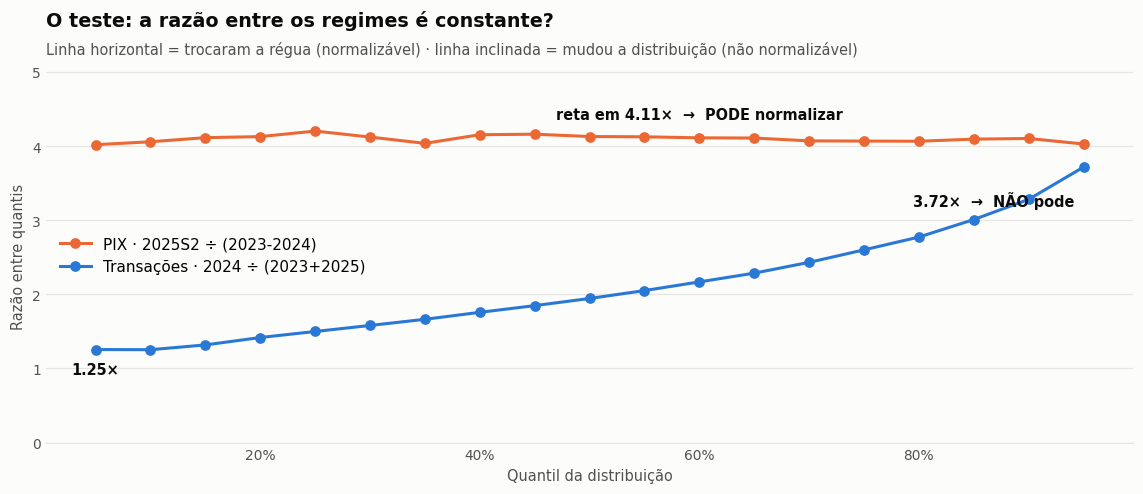

In [27]:
etapa(6, 'Normalizar a escala do PIX')

QS = np.arange(0.05, 1.00, 0.05)

# PIX: antes e depois do corte
p_ok   = pix[pix.Aprovado.fillna(False) & pix.Data.notna() & (pix.Valor > 0)]
px_ref = p_ok.loc[p_ok.Data <  '2025-08-01', 'Valor']
px_alv = p_ok.loc[p_ok.Data >= '2025-08-01', 'Valor']

# Transações: 2024 contra o resto
t_ok   = transac[transac.Autorizado.fillna(False) & (transac.Valor_Compra > 0)]
tx_ref = t_ok.loc[t_ok.Data.dt.year != 2024, 'Valor_Compra']
tx_alv = t_ok.loc[t_ok.Data.dt.year == 2024, 'Valor_Compra']

razao_px = px_alv.quantile(QS).values / px_ref.quantile(QS).values
razao_tx = tx_alv.quantile(QS).values / tx_ref.quantile(QS).values

comparativo = pd.DataFrame({
    'PIX · 2025S2':      [razao_px.min(), razao_px.max(), razao_px.std(),
                          px_ref.std()/px_ref.mean(), px_alv.std()/px_alv.mean()],
    'Transações · 2024': [razao_tx.min(), razao_tx.max(), razao_tx.std(),
                          tx_ref.std()/tx_ref.mean(), tx_alv.std()/tx_alv.mean()],
}, index=['Razão mínima (p5)', 'Razão máxima (p95)', 'Desvio das razões',
          'Coef. de variação ANTES', 'Coef. de variação DEPOIS'])
display(comparativo.style.format('{:.3f}'))

fig, ax = plt.subplots(figsize=(10.5, 4.6))
ax.plot(QS*100, razao_px, color=ORANGE, marker='o', label='PIX · 2025S2 ÷ (2023-2024)')
ax.plot(QS*100, razao_tx, color=BLUE,   marker='o', label='Transações · 2024 ÷ (2023+2025)')
ax.annotate(f'reta em {np.median(razao_px):.2f}×  →  PODE normalizar', (60, razao_px[11]),
            xytext=(0, 12), textcoords='offset points', ha='center',
            fontsize=9.5, fontweight='bold', color=INK)
ax.annotate(f'{razao_tx[0]:.2f}×', (QS[0]*100, razao_tx[0]), xytext=(0, -16),
            textcoords='offset points', ha='center', fontsize=9.5, fontweight='bold', color=INK)
ax.annotate(f'{razao_tx[-1]:.2f}×  →  NÃO pode', (QS[-1]*100, razao_tx[-1]), xytext=(-6, -16),
            textcoords='offset points', ha='right', va='top', fontsize=9.5, fontweight='bold', color=INK)
ax.set_ylim(0, max(razao_px.max(), razao_tx.max())*1.20)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, p: f'{v:.0f}%'))
ax.legend(loc='center left')
eixo(ax, 'O teste: a razão entre os regimes é constante?',
        'Linha horizontal = trocaram a régua (normalizável) · linha inclinada = mudou a distribuição (não normalizável)',
        ylab='Razão entre quantis', xlab='Quantil da distribuição')
plt.tight_layout(); plt.show()

### 6.2 · Aplicando a correção no PIX

**A decisão.** Criar `Valor_norm`, dividindo por ~4,13 apenas de 2025-08 em diante. A coluna `Valor`
original **fica intacta ao lado**.

**Por que manter as duas colunas.** Porque normalização embute uma **premissa**, e premissa tem que ser
auditável. Quem discordar da minha premissa usa a coluna original e refaz. Se eu sobrescrevesse, ninguém
teria como voltar.

**A premissa, dita em voz alta.** Estou assumindo que a **escala** mudou e o **comportamento** não.
Estatisticamente, *"multiplicaram a coluna por 4,13"* e *"todos os clientes passaram a mandar PIX 4,13
vezes maiores"* são **indistinguíveis** — as duas coisas preservam o formato da distribuição.

O que decide a favor da primeira leitura é o **contexto**, não o dado: a mudança é instantânea, atinge
todo mundo igualmente, e acontece exatamente no mês em que a base volta depois de sete meses sem nenhum
registro.

**Um detalhe silencioso que importa.** Existem 591 PIX com valor exatamente zero. Incluí-los no cálculo
muda o fator de **4,1286** para **4,1495**. Diferença pequena, mas é o tipo de escolha invisível que faz
dois relatórios do mesmo time não baterem. Uso `Valor > 0` e deixo isso explícito.

**O que eu descartei.**

1. **Normalizar as transações também** — reprovaram no teste da célula anterior. Seria trocar um erro
   por outro: as compras pequenas ficariam subestimadas e as grandes superestimadas.
2. **Substituir a coluna original** — quem quiser conferir a premissa não teria como.
3. **Não normalizar nada** — perderia a única forma de comparar PIX em reais ao longo da série.

  Fator estimado                     : K = 4.1286
  (mediana das razões p5..p95        :     4.1082  — as duas estimativas convergem)

  Mediana ANTES da correção   :   154.96  vs    639.77   ← 4x de diferença
  Mediana DEPOIS da correção  :   154.96  vs    154.96   ← agora bate

  Linhas normalizadas         : 63.707  (22.8%)
  Coluna `Valor` original     : preservada, para quem quiser conferir a premissa


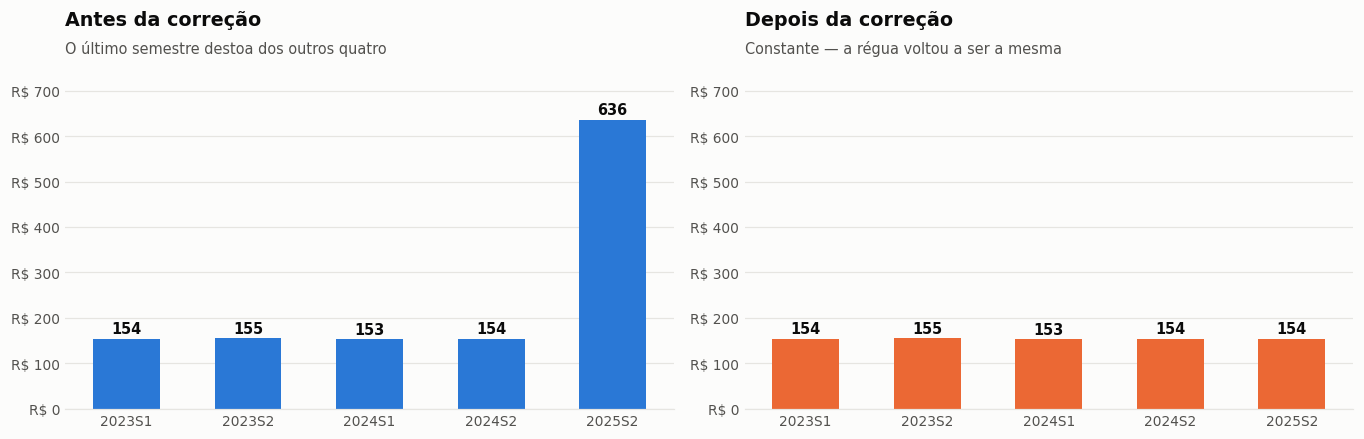

,Antes,Depois
sem,,
2023S1,R$ 153.59,R$ 153.59
2023S2,R$ 154.96,R$ 154.96
2024S1,R$ 152.88,R$ 152.88
2024S2,R$ 153.59,R$ 153.59
2025S2,R$ 636.08,R$ 154.07


  [·] Valor                          63.707 linhas  (22.8%)
      → Criar `Valor_norm` dividindo por 4.1286 de 2025-08 em diante; manter a coluna original
  [i] Valor_Compra                        0 linhas
      → NÃO normalizar. Valores de cartão seguem incomparáveis entre 2023/2025 e 2024


In [28]:
K_PIX = px_alv.median() / px_ref.median()

pix['Valor_norm']       = np.where(pix.Data >= '2025-08-01', pix.Valor / K_PIX, pix.Valor)
pix['flag_normalizado'] = pix.Data >= '2025-08-01'

print(f'  Fator estimado                     : K = {K_PIX:.4f}')
print(f'  (mediana das razões p5..p95        :     {np.median(razao_px):.4f}  — as duas estimativas convergem)')
print()
print(f'  Mediana ANTES da correção   : {px_ref.median():>8.2f}  vs  {px_alv.median():>8.2f}   ← 4x de diferença')
print(f'  Mediana DEPOIS da correção  : {px_ref.median():>8.2f}  vs  {px_alv.median()/K_PIX:>8.2f}   ← agora bate')
print()
print(f'  Linhas normalizadas         : {n(pix.flag_normalizado.sum())}  ({pix.flag_normalizado.mean():.1%})')
print(f'  Coluna `Valor` original     : preservada, para quem quiser conferir a premissa')

# Validação visual: o ticket mediano do envio precisa ficar CONSTANTE após a correção
val = pix[pix.Aprovado.fillna(False) & pix.Data.notna() & ~pix.flag_valor_impossivel
          & (pix.Tipo_transacao == 'Envio')].copy()
val['sem'] = val.Data.dt.year.astype(str) + 'S' + ((val.Data.dt.month > 6).astype(int) + 1).astype(str)

antes_depois = val.groupby('sem').agg(Antes=('Valor','median'), Depois=('Valor_norm','median'))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.1))
for ax, col, cor, tit, sub in [
        (axes[0], 'Antes',  BLUE,   'Antes da correção',  'O último semestre destoa dos outros quatro'),
        (axes[1], 'Depois', ORANGE, 'Depois da correção', 'Constante — a régua voltou a ser a mesma')]:
    x = np.arange(len(antes_depois))
    ax.bar(x, antes_depois[col], width=0.55, color=cor)
    for i, v in enumerate(antes_depois[col]):
        ax.text(i, v + 12, f'{v:,.0f}'.replace(',', '.'), ha='center',
                fontsize=9.5, fontweight='bold', color=INK)
    ax.set_xticks(x, antes_depois.index)
    ax.set_ylim(0, antes_depois.Antes.max()*1.18)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, p: f'R$ {v:,.0f}'.replace(',', '.')))
    eixo(ax, tit, sub)
plt.tight_layout(); plt.show()

display(antes_depois.style.format('R$ {:,.2f}'))

decisao('PIX', 'Valor', 'A partir de 2025-08 todos os valores ficam ~4,13x maiores (troca de escala)',
        int(pix.flag_normalizado.sum()),
        f'Criar `Valor_norm` dividindo por {K_PIX:.4f} de 2025-08 em diante; manter a coluna original',
        'passou no teste de escala pura: razão constante de 4,02 a 4,20 em toda a distribuição e formato preservado (CV 1,108 → 1,107)',
        'Normalizar também as transações (reprovaram no teste) ou substituir a coluna original (impediria auditar a premissa)')

decisao('Transações', 'Valor_Compra', 'Em 2024 os valores seguem outra distribuição', 0,
        'NÃO normalizar. Valores de cartão seguem incomparáveis entre 2023/2025 e 2024',
        'a razão entre os regimes vai de 1,25 nas compras pequenas a 3,72 nas grandes — não houve multiplicação, mudou a distribuição inteira',
        'Dividir 2024 por um fator médio: as compras pequenas ficariam subestimadas e as grandes superestimadas',
        tipo='Documentação')

### 6.3 · O aviso mais importante deste notebook

Investigando **por que** as transações não normalizavam, apareceu algo que muda como toda a base deve
ser usada.

O regime "normal" das transações — 2023 e 2025, dois terços dos dados — é uma **distribuição uniforme
entre R$ 0 e R$ 1.200**. Rode a célula: os quantis observados caem praticamente em cima da diagonal
teórica, e apenas 0,09% das compras passam de R$ 1.200.

Consumo real **nunca** tem esse formato. Gasto de cartão é fortemente assimétrico: muitas compras
pequenas, poucas grandes. Uma reta perfeita significa que a coluna `Valor_Compra` foi **sorteada**, não
observada.

> ### A consequência prática
>
> **O valor da transação não carrega informação nesta base.** Ticket médio, "clientes de alto valor",
> gasto por faixa de renda — nada disso tem significado, porque o valor foi sorteado independentemente
> do cliente.
>
> Isso explica por que a correlação entre renda anual e gasto em 2025 é de **−0,05**: não há nada para
> correlacionar.

É por isso que todo o diagnóstico do notebook de análise foi construído sobre **contagens, frequência e
participações** — que refletem comportamento — e não sobre reais.

**A decisão.** Documentar. Nenhum tratamento resolve isso; o que resolve é não usar a coluna para o que
ela não serve.

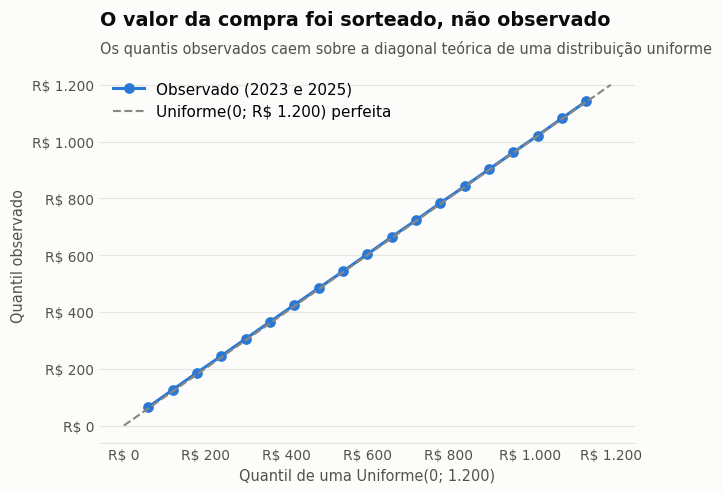

  p25 observado: R$     306   ·   uniforme diria: R$ 300
  p50 observado: R$     603   ·   uniforme diria: R$ 600
  p75 observado: R$     903   ·   uniforme diria: R$ 900

  Compras acima de R$ 1.200: 0.09%
  [i] Valor_Compra                        0 linhas
      → Documentar: o valor da compra NÃO deve ser usado como variável analítica


In [29]:
teorico = 1200 * QS

fig, ax = plt.subplots(figsize=(6.5, 4.6))
ax.plot(teorico, tx_ref.quantile(QS).values, color=BLUE, marker='o', label='Observado (2023 e 2025)')
ax.plot([0, 1200], [0, 1200], color=INK3, ls='--', lw=1.4, label='Uniforme(0; R$ 1.200) perfeita')
ax.legend(loc='upper left')
for f in [ax.xaxis, ax.yaxis]:
    f.set_major_formatter(FuncFormatter(lambda v, p: f'R$ {v:,.0f}'.replace(',', '.')))
eixo(ax, 'O valor da compra foi sorteado, não observado',
        'Os quantis observados caem sobre a diagonal teórica de uma distribuição uniforme',
        xlab='Quantil de uma Uniforme(0; 1.200)', ylab='Quantil observado')
plt.tight_layout(); plt.show()

print(f'  p25 observado: R$ {tx_ref.quantile(.25):>7.0f}   ·   uniforme diria: R$ 300')
print(f'  p50 observado: R$ {tx_ref.quantile(.50):>7.0f}   ·   uniforme diria: R$ 600')
print(f'  p75 observado: R$ {tx_ref.quantile(.75):>7.0f}   ·   uniforme diria: R$ 900')
print(f'\n  Compras acima de R$ 1.200: {100*(tx_ref > 1200).mean():.2f}%')

decisao('Transações', 'Valor_Compra',
        'Em 2023 e 2025 os valores seguem uma distribuição uniforme entre R$ 0 e R$ 1.200', 0,
        'Documentar: o valor da compra NÃO deve ser usado como variável analítica',
        'os quantis caem em cima da diagonal teórica e só 0,09% passa de R$ 1.200 — consumo real nunca tem esse formato, o campo parece sorteado',
        'Usar ticket médio e "cliente de alto valor": seriam métricas sobre um número aleatório',
        tipo='Documentação')

### 6.4 · Redundâncias · não é erro, mas vale registrar

Duas coisas que não precisam de tratamento, só de conhecimento:

- **`Cidade` e `Estado`** são equivalentes: 6 cidades em 6 estados, uma por estado. A segunda coluna não
  acrescenta informação nenhuma.
- **`Input_Mode` e `Input_Mode_Code`** também: cada código corresponde sempre ao mesmo modo de entrada.

Mantenho as duas de cada par. Remover economizaria espaço e criaria atrito com quem espera a coluna no
arquivo — e no caso do `Input_Mode_Code`, é o formato que os sistemas Mastercard usam de verdade.

In [30]:
print('Cidade → Estado:')
print(' ', clientes.groupby('Estado').Cidade.unique().apply(lambda x: x[0]).to_dict())
print(f'\n  Cidades por estado: {clientes.groupby("Estado").Cidade.nunique().unique()}  → sempre 1')
print(f'  Códigos por modo de entrada: {transac.groupby("Input_Mode").Input_Mode_Code.nunique().unique()}  → sempre 1')

decisao('Clientes', 'Cidade / Estado', 'As duas colunas são equivalentes: uma cidade por estado',
        len(clientes), 'Manter as duas e documentar a redundância',
        'são 6 cidades em 6 estados, relação um para um — a segunda não acrescenta informação',
        'Remover uma delas: criaria atrito com quem espera a coluna no arquivo', tipo='Documentação')

decisao('Transações', 'Input_Mode / Input_Mode_Code', 'As duas colunas são equivalentes',
        len(transac), 'Manter as duas e documentar a redundância',
        'cada código corresponde sempre ao mesmo modo de entrada — é a mesma informação em dois formatos',
        'Remover o código numérico: é o formato que os sistemas Mastercard usam de verdade', tipo='Documentação')

Cidade → Estado:
  {'BA': 'Salvador', 'MG': 'Belo Horizonte', 'PR': 'Curitiba', 'RJ': 'Rio de Janeiro', 'RS': 'Porto Alegre', 'SP': 'São Paulo'}

  Cidades por estado: [1]  → sempre 1
  Códigos por modo de entrada: [1]  → sempre 1
  [i] Cidade / Estado                 1.960 linhas  (100.0%)
      → Manter as duas e documentar a redundância
  [i] Input_Mode / Input_Mode_Code  156.826 linhas  (100.0%)
      → Manter as duas e documentar a redundância


---
# Etapa 7 · Conferir, salvar e explicar

### 7.1 · A conferência mais importante do notebook

A regra de ouro dizia: **nenhuma linha é excluída**. Aqui eu **provo** isso, em vez de pedir que
acreditem.

A célula compara a contagem de cada base com a foto tirada na Etapa 0. Se qualquer uma tiver perdido uma
linha sequer, o `assert` dispara e o notebook **para** — nada é salvo.

É a diferença entre dizer "eu não apaguei nada" e demonstrar.

In [31]:
etapa(7, 'Conferir, salvar e explicar')

TRATADAS = {'Clientes': clientes, 'Cartões': cartoes, 'Transações': transac,
            'PIX': pix, 'Investimentos': invest}
ARQUIVOS = {'Clientes': 'clientes', 'Cartões': 'cartoes', 'Transações': 'transacoes',
            'PIX': 'pix', 'Investimentos': 'investimentos'}

print('  Nenhuma linha pode ter sido perdida:\n')
falhou = False
for nome, df in TRATADAS.items():
    antes_, depois_ = LINHAS_ANTES[nome], len(df)
    ok_ = antes_ == depois_
    falhou |= not ok_
    print(f'    {"OK  " if ok_ else "ERRO"}  {nome:<15} {n(antes_):>9} → {n(depois_):>9}   '
          f'(+{df.shape[1] - pd.read_csv(PASTA / f"Base_{ARQUIVOS[nome]}_v4.csv", nrows=1).shape[1]} colunas novas)')

assert not falhou, 'ABORTADO: alguma base perdeu linhas. Isso viola a regra de ouro do notebook.'
print('\n  Conferência passou. Nenhuma linha foi excluída.')


────────────────────────────────────────────────────────────────────────────
  ETAPA 7 · Conferir, salvar e explicar
────────────────────────────────────────────────────────────────────────────
  Nenhuma linha pode ter sido perdida:

    OK    Clientes            1.960 →     1.960   (+4 colunas novas)
    OK    Cartões             4.006 →     4.006   (+4 colunas novas)
    OK    Transações        156.826 →   156.826   (+8 colunas novas)
    OK    PIX               278.940 →   278.940   (+7 colunas novas)
    OK    Investimentos      21.200 →    21.200   (+4 colunas novas)

  Conferência passou. Nenhuma linha foi excluída.


### 7.2 · O que ficou marcado

As flags não escondem nada — elas **mostram**. Cada linha marcada continua na base; a flag só diz onde
olhar.

Repare na proporção: `flag_antes_da_conta` sozinha atinge um quarto da base PIX. Se essas linhas tivessem
sido apagadas em silêncio, o notebook de análise estaria trabalhando com 75% dos dados sem que ninguém
soubesse.

Base,Flag,Linhas,Pct
Transações,flag_parcelas_nao_informado,"113,252",72.22%
PIX,flag_antes_da_conta,"69,427",24.89%
PIX,flag_normalizado,"63,707",22.84%
Cartões,flag_sem_dono,469,11.71%
Transações,flag_debito_parcelado,"6,852",4.37%
Clientes,flag_sem_atividade,85,4.34%
Transações,flag_cartao_vencido,"2,700",1.72%
Transações,flag_antes_ativacao,"2,131",1.36%
Investimentos,flag_vencimento_passado,188,0.89%
PIX,flag_valor_impossivel,917,0.33%


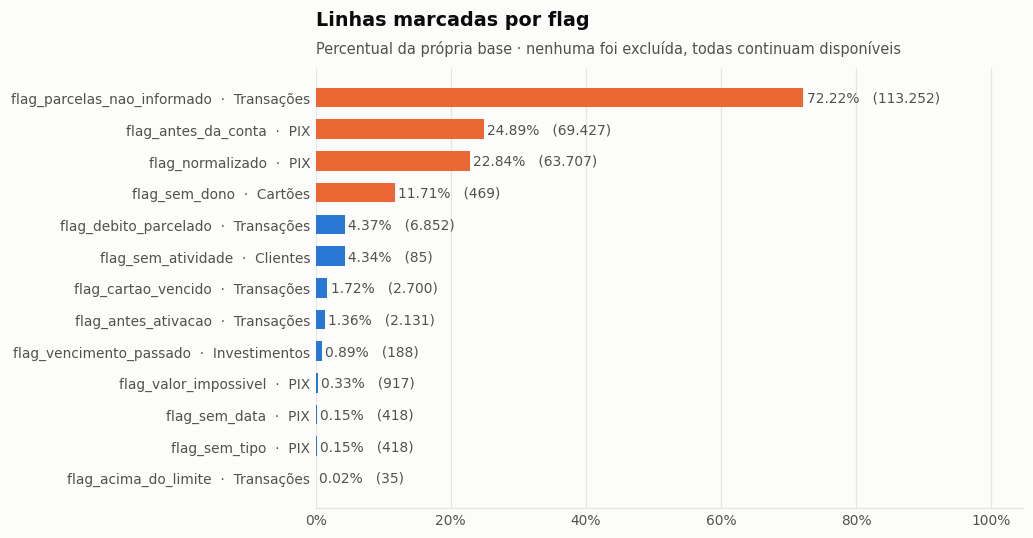

In [32]:
resumo_flags = []
for nome, df in TRATADAS.items():
    for f in [c for c in df.columns if c.startswith('flag_')]:
        q = int(df[f].fillna(False).sum())
        resumo_flags.append(dict(Base=nome, Flag=f, Linhas=q, Pct=round(100*q/len(df), 2)))

flags_df = pd.DataFrame(resumo_flags).sort_values('Pct', ascending=False)
display(flags_df.style.hide(axis='index').format({'Linhas': '{:,.0f}', 'Pct': '{:.2f}%'}))

fig, ax = plt.subplots(figsize=(9.5, 5))
y = np.arange(len(flags_df))[::-1]
cores = [ORANGE if p > 10 else BLUE for p in flags_df.Pct]
ax.barh(y, flags_df.Pct, height=0.62, color=cores)
ax.set_yticks(y, [f'{r.Flag}  ·  {r.Base}' for r in flags_df.itertuples()], fontsize=9)
for yi, (p, q) in zip(y, zip(flags_df.Pct, flags_df.Linhas)):
    ax.text(p + 0.5, yi, f'{p:.2f}%   ({n(q)})', va='center', fontsize=9, color=INK2)
ax.grid(axis='x'); ax.grid(axis='y', visible=False)
ax.set_xlim(0, max(flags_df.Pct)*1.45)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, p: f'{v:.0f}%'))
eixo(ax, 'Linhas marcadas por flag',
        'Percentual da própria base · nenhuma foi excluída, todas continuam disponíveis')
plt.tight_layout(); plt.show()

### 7.3 · As colunas que cada base ganhou

Vale conferir antes de salvar: nenhuma coluna original foi removida, e as novas estão todas lá.

In [33]:
novas = []
for nome, df in TRATADAS.items():
    orig = set(pd.read_csv(PASTA / f'Base_{ARQUIVOS[nome]}_v4.csv', nrows=1).columns)
    novas.append(dict(Base=nome,
                      Colunas_originais=len(orig),
                      Colunas_novas=len([c for c in df.columns if c not in orig]),
                      Total=df.shape[1],
                      Removidas=len(orig - set(df.columns)),
                      Novas=', '.join(c for c in df.columns if c not in orig)))
display(pd.DataFrame(novas).style.hide(axis='index'))
print('\n  Coluna "Removidas" em zero: nenhuma coluna original foi descartada.')

Base,Colunas_originais,Colunas_novas,Total,Removidas,Novas
Clientes,8,4,12,0,"cadastro_incompleto, idade, meses_de_casa, flag_sem_atividade"
Cartões,7,4,11,0,"ativado, Cliente_ID, flag_sem_dono, usado"
Transações,14,8,22,0,"flag_parcelas_nao_informado, parcelado, usou_wallet, tipo_evento, flag_cartao_vencido, flag_antes_ativacao, flag_debito_parcelado, flag_acima_do_limite"
PIX,8,7,15,0,"id_pix, flag_valor_impossivel, flag_sem_data, flag_sem_tipo, flag_antes_da_conta, Valor_norm, flag_normalizado"
Investimentos,7,4,11,0,"produto_perpetuo, tipo_evento, saldo_fechamento, flag_vencimento_passado"



  Coluna "Removidas" em zero: nenhuma coluna original foi descartada.


### 7.4 · Salvar as bases tratadas

In [34]:
print('  Gravando em bases_tratadas/:\n')
for nome, df in TRATADAS.items():
    caminho = SAIDA / f'{ARQUIVOS[nome]}_tratado.csv'
    df.to_csv(caminho, index=False, encoding='utf-8-sig')   # utf-8-sig para abrir certo no Excel
    print(f'    {caminho.name:<30} {n(len(df)):>9} linhas × {df.shape[1]:>2} colunas   '
          f'({caminho.stat().st_size/1e6:.1f} MB)')

  Gravando em bases_tratadas/:

    clientes_tratado.csv               1.960 linhas × 12 colunas   (0.2 MB)
    cartoes_tratado.csv                4.006 linhas × 11 colunas   (0.4 MB)


    transacoes_tratado.csv           156.826 linhas × 22 colunas   (21.5 MB)


    pix_tratado.csv                  278.940 linhas × 15 colunas   (31.6 MB)
    investimentos_tratado.csv         21.200 linhas × 11 colunas   (1.9 MB)


### 7.5 · O relatório de qualidade

O relatório é gerado a partir da **mesma lista** de decisões que o notebook executou. Isso significa que
ele **não pode ficar desatualizado** em relação ao código: se eu mudar um tratamento e não mexer no
texto, o texto muda junto.

Saem dois arquivos: um CSV para abrir no Excel e um `.md` para ler direto no GitHub — que é como a
entrega do desafio é feita.

In [35]:
relatorio = pd.DataFrame(DECISOES)
relatorio.to_csv(PASTA / 'relatorio_qualidade.csv', index=False, encoding='utf-8-sig')
flags_df.to_csv(PASTA / 'relatorio_flags.csv', index=False, encoding='utf-8-sig')

print(f'  {len(relatorio)} decisões registradas:\n')
display(relatorio.Tipo.value_counts().rename('Quantidade').to_frame())
display(relatorio[['Etapa','Base','Campo','Tipo','Linhas_afetadas']]
        .style.hide(axis='index').format({'Linhas_afetadas': '{:,.0f}'}))

# --- Gera o TRATAMENTO.md a partir do mesmo registro ---
linhas_md = [
    '# Tratamento das bases — Priceless Bank', '',
    'Documento gerado automaticamente pelo notebook `2_limpeza_de_dados.ipynb`.',
    'Cada seção corresponde a uma decisão que o notebook realmente executou — o texto não pode ficar',
    'desatualizado em relação ao código porque os dois saem da mesma fonte.', '',
    '## A regra que orienta tudo', '',
    '> **Nenhuma linha é excluída.** O que não pode ser corrigido é marcado com uma coluna `flag_*`,',
    '> e quem for analisar decide se filtra. Apagar dado é irreversível e invisível; marcar é',
    '> reversível e auditável.', '',
    'O notebook confere isso na Etapa 7: se qualquer base perder uma linha, ele para sem salvar.', '',
    '## Resumo', '',
    f'- **{len(relatorio)} decisões** registradas',
    f'- **{int((relatorio.Tipo == "Flag").sum())} flags** de inconsistência criadas',
    f'- **{int((relatorio.Tipo == "Coluna nova").sum())} colunas novas** derivadas',
    f'- **{int((relatorio.Tipo == "Tratamento").sum())} tratamentos** aplicados',
    f'- **{int((relatorio.Tipo == "Documentação").sum())} pontos** apenas documentados, sem alterar dado',
    '- **0 linhas excluídas**', '',
]
for et, bloco in relatorio.groupby('Etapa', sort=False):
    linhas_md += [f'## Etapa {et}', '']
    for _, r in bloco.iterrows():
        qtd = n(r.Linhas_afetadas) if r.Linhas_afetadas else '—'
        linhas_md += [f'### `{r.Campo}` · {r.Base}', '',
                      f'**O problema.** {r.Problema}. Linhas afetadas: **{qtd}**.', '',
                      f'**O que eu faço.** {r.Decisao}.', '',
                      f'**Por quê.** Porque {r.Por_que}.', '',
                      f'**O que eu descartei.** {r.Alternativa_descartada}.', '']

linhas_md += [
    '## Como usar as bases tratadas', '', '```python', 'import pandas as pd', '',
    "pix = pd.read_csv('bases_tratadas/pix_tratado.csv')", '',
    '# Somar valores de PIX: use a coluna normalizada e tire os valores corrompidos',
    'validos = pix[~pix.flag_valor_impossivel & ~pix.flag_sem_data]',
    'total   = validos.Valor_norm.sum()', '',
    '# Quer conferir a premissa da normalização? A coluna original continua lá:',
    'total_sem_normalizar = validos.Valor.sum()', '```', '',
    '**Uma advertência que vale repetir:** não use `Valor_Compra` como variável analítica.',
    'Em 2023 e 2025 ela segue uma distribuição uniforme entre R$ 0 e R$ 1.200, o que indica que o',
    'campo foi sorteado e não observado. Use contagem de transações.', '',
]
(PASTA / 'TRATAMENTO.md').write_text('\n'.join(linhas_md), encoding='utf-8')

print('  relatorio_qualidade.csv   ·  uma linha por decisão, para abrir no Excel')
print('  relatorio_flags.csv       ·  contagem de cada flag')
print('  TRATAMENTO.md             ·  o mesmo conteúdo em texto (saída local, não versionada)')
print(f'\n{"═"*76}')
print('PRONTO'.center(76))
print(f'{"═"*76}')
print(f'  {len(relatorio)} decisões  ·  {int((relatorio.Tipo=="Flag").sum())} flags  ·  '
      f'{int((relatorio.Tipo=="Coluna nova").sum())} colunas novas  ·  0 linhas excluídas')
print(f'{"═"*76}')

  30 decisões registradas:



,Quantidade
Tipo,
Flag,10
Tratamento,9
Documentação,6
Coluna nova,5


Etapa,Base,Campo,Tipo,Linhas_afetadas
1. Padronizar tipos e datas,Todas,colunas de data,Tratamento,0
1. Padronizar tipos e datas,Todas,Sim/Não e 0/1,Tratamento,0
2. Preencher o que não é buraco,Transações,Qtd_Parcelas,Tratamento,"113,252"
2. Preencher o que não é buraco,Transações,Wallet,Tratamento,"134,716"
2. Preencher o que não é buraco,Cartões,Data_Ativacao,Tratamento,450
2. Preencher o que não é buraco,Investimentos,Data_de_vencimento,Tratamento,"7,864"
2. Preencher o que não é buraco,Investimentos,Valor_Aplicado / Saldo_Atual,Tratamento,14
2. Preencher o que não é buraco,Clientes,Renda_Anual,Tratamento,255
3. Marcar o que não tem salvação,Transações,Crossborder,Documentação,"149,912"
3. Marcar o que não tem salvação,Transações,Contactless,Documentação,"129,332"


  relatorio_qualidade.csv   ·  uma linha por decisão, para abrir no Excel
  relatorio_flags.csv       ·  contagem de cada flag
  TRATAMENTO.md             ·  o mesmo conteúdo em texto (saída local, não versionada)

════════════════════════════════════════════════════════════════════════════
                                   PRONTO                                   
════════════════════════════════════════════════════════════════════════════
  30 decisões  ·  10 flags  ·  5 colunas novas  ·  0 linhas excluídas
════════════════════════════════════════════════════════════════════════════


---
## Como usar as bases tratadas

```python
import pandas as pd

pix      = pd.read_csv('bases_tratadas/pix_tratado.csv')
clientes = pd.read_csv('bases_tratadas/clientes_tratado.csv')

# Somar valores de PIX: use a coluna normalizada e tire os valores corrompidos
validos = pix[~pix.flag_valor_impossivel & ~pix.flag_sem_data]
total   = validos.Valor_norm.sum()

# Discorda da premissa da normalização? A coluna original continua lá:
total_sem_normalizar = validos.Valor.sum()
```

**A advertência que vale repetir:** não use `Valor_Compra` como variável analítica. Em 2023 e 2025 ela
segue uma distribuição uniforme entre R$ 0 e R$ 1.200 — o campo foi sorteado, não observado. Use
**contagem** de transações.

---

## O que ficou de fora, de propósito

Três coisas que **não** dá para tratar, e é importante saber:

1. **Os 7 meses ausentes do PIX** (jan a jul de 2025). Não existe tratamento para dado que não foi
   entregue. Qualquer imputação inventaria 7 meses de comportamento.
2. **`Crossborder` e `Contactless`.** Vazias demais, e o que sobra é 50/50. Ficam no arquivo, mas
   documentadas como inutilizáveis.
3. **A escala das transações de 2024.** Reprovou no teste da Etapa 6. Segue incomparável, e agora
   sabemos exatamente por quê.

---

## Uma última palavra sobre método

Nenhuma das decisões deste notebook é a única possível. Outro analista poderia, com boa fé, excluir os
917 PIX corrompidos em vez de marcá-los, ou decidir não normalizar nada.

O que **não** é aceitável é tomar essas decisões **sem registrar**. Uma base tratada sem relatório é uma
base em que ninguém sabe o que aconteceu — inclusive quem a tratou, três semanas depois.

Por isso o campo *"o que eu descartei"* aparece em todas as decisões. Ele é o que transforma
*"tratei os dados"* em *"tomei decisões defensáveis, e aqui estão elas".*